<br>
<div style="text-align:center;">
    <span style="color:#99BBF4; font-size:33px; font-weight:bold;">
       NOTEBOOK 2 v1.0. MODELO RANDOM FOREST DE VARIABLES ACÚSTICAS CON VALIDACIÓN PARA CLASIFICACIÓN ALS VS HC
    </span>
</div>

<div style="text-align:center;">
    <span style="color:#6593BA; font-size:22px; font-weight:bold;">
        Trabajo Fin de Grado
    </span>
    <br>
    <span style="color:#6593BA; font-size:20px; font-weight:bold;">
        Ingeniería Biomédica Curso 2025/2026
    </span>
</div>
<br>

<br>
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">
        ÍNDICE
    </span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       INTRODUCCIÓN
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        1. Introducción y objetivos del experimento
        <br>
        2. Configuración técnica y variables globales
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 1. PREPARACIÓN DE DATOS Y DEFINICIÓN DEL PROBLEMA
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        3. Carga y verificación de los datos
        <br>
        4. Definición del problema supervisado
        <br>
        5. Estrategia de validación y control de fuga de información
        <br>
        6. Definición de conjuntos de features
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 2. PIPELINE DE PREPROCESAMIENTO
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        7. Diseño del pipeline de preprocesamiento
        <br>
        8. Limpieza de columnas mal tipadas
        <br>
        9. Tratamiento de variables numéricas
        <br>
        10. Tratamiento de variables categóricas
        <br>
        11. Construcción del ColumnTransformer
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 3. DEFINICIÓN DEL MODELO Y OPTIMIZACIÓN
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        12. Definición del modelo y estrategia de optimización
        <br>
        13. Feature Selection con SelectKBest
        <br>
        14. Grid Search de hiperparámetros
        <br>
        15. Construcción del Pipeline completo
        <br>
        16. Nested Cross-Validation
        <br>
        17. Entrenamiento del modelo final
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 4. EVALUACIÓN DEL MODELO
    </span>
</div>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 5. CALIBRACIÓN DE PROBABILIDADES
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        23. Entrenamiento de modelos calibrados
        <br>
        24. Curvas ROC — CV vs Test
        <br>
        25. Curvas de calibración
        <br>
        26. Distribución de probabilidades
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       CONCLUSIONES
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        27. Resumen de las conclusiones finales
        <br>
</span>

#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">
        INTRODUCCIÓN
    </span>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 1. Introducción y objetivos del experimento</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Este notebook desarrolla un modelo de <b>Random Forest</b> para clasificación binaria entre pacientes con Esclerosis Lateral Amiotrófica (ALS) y controles sanos (HC), aplicado sobre variables acústicas del habla extraídas del dataset VOC-ALS.
<br><br>
El punto de partida es una premisa clínica que propone que la ELA produce, en una proporción significativa de casos, afectación bulbar progresiva que compromete los mecanismos neuromusculares del habla. Esta alteración se manifiesta como disartria, una degradación de la articulación, la prosodia y la calidad vocal que puede ser capturada y cuantificada mediante análisis acústico. Variables como la frecuencia fundamental (F0), el HNR (<i>Harmonics-to-Noise Ratio</i>), el jitter y el shimmer reflejan directamente la estabilidad del control motor laríngeo y articulatorio, y constituyen por tanto parámetros cuantificables de la integridad del sistema nervioso motor.
    </span> 
</div>

<div style="text-align:left;color:#6593BA;"> 
    <span style="font-size:20px; font-family:Calibri; text-align:justify; display: inline-block;"> 
        <strong>Planteamiento del experimento</strong>
    </span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El experimento se formula como un problema de clasificación supervisada binaria. La variable objetivo es <code>Category</code> ∈ {ALS, HC} y el conjunto de predictores utiliza las <b>50 variables acústicas</b> disponibles en el dataset, derivadas de cinco métricas (meanF0Hz, stdevF0Hz, HNR, localJitter, localShimmer) calculadas sobre diez tareas vocales diferentes:
<br>
<ul>
<li>Vocales sostenidas: A, E, I, O, U</li>
<li>Sílabas repetidas: PA, TA, KA</li>
<li>Lectura en voz alta (reading)</li>
<li>Habla espontánea sobre días laborables (weekdays)</li>
</ul>
Esta configuración permite evaluar de forma aislada la capacidad discriminativa de la señal vocal sin añadir complejidad innecesaria mediante variables demográficas o clínicas.
    </span> 
</div>

<div style="text-align:left;color:#6593BA;"> 
    <span style="font-size:20px; font-family:Calibri; text-align:justify; display: inline-block;"> 
        <strong>Mejoras metodológicas implementadas</strong>
    </span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este notebook incorpora ciertas mejoras sobre etapas iniciales del modelo, orientadas a controlar el overfitting y garantizar estimaciones conservadoras del rendimiento:
<br><br>
<ul>
<li><b>Nested Cross-Validation (5×3):</b> Estimación no sesgada del rendimiento mediante validación cruzada anidada. El loop externo (5 folds) evalúa el rendimiento, mientras que el loop interno (3 folds) optimiza hiperparámetros en cada fold externo de forma independiente.</li>
<li><b>Feature Selection integrada:</b> Reducción dimensional mediante <code>SelectKBest</code> con test ANOVA F, integrado en el pipeline. Esto permite evaluar diferentes configuraciones de número de features (k=10, 15, 20) sin introducir data leakage.</li>
<li><b>Grid Search exhaustivo:</b> Búsqueda sistemática de hiperparámetros mediante <code>GridSearchCV</code>. Se exploran 288 combinaciones de <code>n_estimators</code>, <code>max_depth</code>, <code>min_samples_split</code>, <code>min_samples_leaf</code>, <code>class_weight</code> y <code>feature_selection__k</code> para identificar la configuración óptima.</li>
<li><b>Permutation Importance:</b> Análisis de importancia de variables mediante permutación sobre el conjunto CV completo tras entrenar el modelo final. Este método no presenta los sesgos sistemáticos de MDI (Mean Decrease Impurity) hacia variables continuas o de alta cardinalidad.</li>
<li><b>MLflow Tracking:</b> Registro automático de todos los experimentos, métricas, hiperparámetros y artefactos mediante MLflow. Esto garantiza trazabilidad completa y reproducibilidad total del proceso.</li>
<li><b>Test Set Hold-out:</b> Evaluación final en conjunto completamente no visto hasta el momento de la evaluación definitiva. El test set nunca interviene en ninguna decisión de modelado.</li>
<li><b>Auditoría de Data Leakage:</b> Verificaciones automáticas de integridad del split por ID de sujeto, asegurando que ningún paciente aparezca simultáneamente en el pool CV y en test, ni en más de un fold.</li>
</ul>
</span>
</div>

<div style="text-align:left;color:#6593BA;"> 
    <span style="font-size:20px; font-family:Calibri; text-align:justify; display: inline-block;"> 
        <strong>Consideraciones metodológicas </strong>
    </span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El diseño de los experimentos incorpora las siguientes decisiones técnicas:
<br><br>
<ul>
<li><b>Split por sujeto:</b> La partición se gestiona a nivel de paciente (ID), no de muestra. El fichero <code>subject_split.csv</code> conserva el <i>hold-out</i> de test y el notebook reconstruye los folds de CV a partir del pool Train+Validation original, evitando fuga de sujetos entre entrenamiento, validación cruzada y evaluación final.</li>
<br>
<li><b>Pipeline encapsulado:</b> Todas las transformaciones de preprocesamiento (imputación de valores ausentes, escalado de variables numéricas, feature selection) se integran dentro de un objeto <code>Pipeline</code> de scikit-learn. Esto asegura que el ajuste de estas transformaciones (cálculo de medianas, medias, rangos, selección de features) se realice exclusivamente sobre los datos de entrenamiento de cada fold. Aplicar, por ejemplo, una imputación global antes del split equivaldría a contaminar el proceso con información estadística del resto del pool CV o del test hold-out, inflando artificialmente las métricas.</li>
<br>
<li><b>Tratamiento de columnas con tipado mixto:</b> Varias columnas clínicas del dataset (<code>FVC%</code>, <code>DiagnosticDelay</code>, <code>DiseaseDuration</code>) presentan el valor <code>"-"</code> para los controles sanos, lo que provoca que pandas las infiera como tipo <code>object</code> en lugar de <code>float</code>. La solución adoptada es aplicar <code>pd.to_numeric(errors='coerce')</code> sobre estas columnas antes de la entrada al pipeline, transformando los strings no numéricos en <code>NaN</code>. El <code>SimpleImputer</code> del pipeline los imputa posteriormente con la mediana del conjunto de entrenamiento, sin comprometer la integridad del split.</li>
<br>
<li><b>Regularización del Random Forest:</b> Se aplican restricciones sobre los hiperparámetros del árbol para controlar el overfitting: <code>max_depth</code> limitado, <code>min_samples_split</code> y <code>min_samples_leaf</code> incrementados, y evaluación de <code>class_weight='balanced'</code> para manejar el desbalanceo de clases (67% ALS vs 33% HC).</li>
<br>
<li><b>Limitaciones del dataset:</b> El tamaño muestral (n=153 sujetos, con un pool CV derivado de Train+Validation y un test hold-out separado) sigue siendo una restricción importante para el rendimiento alcanzable. El ratio original muestras/features es bajo y favorece la inestabilidad entre folds; la feature selection con SelectKBest mitiga parcialmente este problema reduciendo la dimensionalidad a 10-20 features.</li>
</ul>
    </span> 
</div>

#
<br>
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 2. Configuración técnica y variables globales</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Se importan todas las librerías necesarias para el experimento y se fijan las rutas del dataset, el split y el directorio de resultados. La semilla global <code>SEED = 42</code> se aplica a NumPy, Python random y la variable de entorno <code>PYTHONHASHSEED</code> para garantizar la reproducibilidad total del experimento. Se configura también el experimento de MLflow bajo el que se registrarán todos los runs generados en este notebook.
    </span>
</div>

In [44]:
# CONFIGURACIÓN DEL ENTORNO
import os
import sys
import sys
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import json
import yaml
import subprocess
from datetime import datetime

# Machine Learning
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
from sklearn.metrics import roc_curve, roc_auc_score, auc 
from sklearn.metrics import precision_score
from sklearn.calibration import CalibratedClassifierCV, calibration_curve 
from sklearn.metrics import brier_score_loss
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import (
    StratifiedKFold, GridSearchCV, cross_validate, cross_val_predict,
    StratifiedGroupKFold, PredefinedSplit
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, make_scorer,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, balanced_accuracy_score
)
from sklearn.inspection import permutation_importance

# MLflow para experiment tracking
import mlflow
import mlflow.sklearn

# Configuración de visualización
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# SEMILLA PARA REPRODUCIBILIDAD 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print("Librerías importadas correctamente")
print(f"  Python:       {sys.version.split()[0]}")
print(f"  NumPy:        {np.__version__}")
print(f"  Pandas:       {pd.__version__}")
print(f"  Scikit-learn: {__import__('sklearn').__version__}")
print(f"  MLflow:       {mlflow.__version__}")

Librerías importadas correctamente
  Python:       3.10.0
  NumPy:        2.2.6
  Pandas:       2.3.3
  Scikit-learn: 1.7.2
  MLflow:       3.10.1


In [45]:
# CONFIG + RUTAS (parametrizadas vía config.yaml)
def load_config():
    """Busca config.yaml hacia arriba desde CWD o via env var TFG_CONFIG."""
    cfg_path = os.environ.get("TFG_CONFIG")
    if cfg_path is None:
        for parent in [Path.cwd(), *Path.cwd().parents]:
            if (parent / "config.yaml").exists():
                cfg_path = parent / "config.yaml"
                break
    if cfg_path is None:
        raise FileNotFoundError(
            "No se encuentra config.yaml. Crea uno en la raíz del repo o define TFG_CONFIG."
        )
    with open(cfg_path) as f:
        cfg = yaml.safe_load(f)
    root = Path(cfg_path).resolve().parent
    for k, v in cfg["paths"].items():
        p = Path(v)
        cfg["paths"][k] = str((root / p).resolve()) if not p.is_absolute() else str(p)
    return cfg

CONFIG = load_config()

DATASET_PATH = CONFIG["paths"]["dataset"]
SPLIT_PATH   = Path(CONFIG["paths"]["splits"]) / "subject_split.csv"
RESULTS_PATH = Path(CONFIG["paths"]["results"]) / "02_rf_v1_0"
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

SHEET_NAME = CONFIG["dataset"]["sheet_name"]
TARGET     = CONFIG["dataset"]["target_col"]
ID_COL     = CONFIG["dataset"]["id_col"]
SEED       = CONFIG["seed"]

# SEED global (ya definido arriba, pero refrescamos por si se re-ejecuta esta celda)
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# MLflow
mlflow.set_tracking_uri(Path(CONFIG["paths"]["mlruns"]).resolve().as_uri())
mlflow.set_experiment("rf_v1.0")

# Helpers de persistencia
def _git_commit():
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "--short", "HEAD"],
            stderr=subprocess.DEVNULL
        ).decode().strip()
    except Exception:
        return "unknown"

def save_metrics(metrics_dict, path, model_name, phase, extra=None):
    assert phase in {"cv", "test"}, "phase debe ser 'cv' o 'test'"
    payload = {
        "model": model_name,
        "phase": phase,
        "metrics": metrics_dict,
        "generated_at": datetime.now().isoformat(timespec="seconds"),
        "git_commit": _git_commit(),
    }
    if extra:
        payload.update(extra)
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False, default=float)
    print(f"Guardado: {path}")

print(f"Config cargado. Project root: {CONFIG['paths']['project_root']}")
print(f"Dataset:     {DATASET_PATH}")
print(f"Split:       {SPLIT_PATH}")
print(f"Results:     {RESULTS_PATH}")

Config cargado. Project root: C:\Users\Laura\OneDrive\TFG
Dataset:     C:\Users\Laura\OneDrive\TFG\artifacts\metadata\VOC-ALS.xlsx
Split:       C:\Users\Laura\OneDrive\TFG\artifacts\splits\subject_split.csv
Results:     C:\Users\Laura\OneDrive\TFG\results\02_rf_v1_0


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 1. PREPARACIÓN DE DATOS Y DEFINICIÓN DEL PROBLEMA</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este bloque establece la infraestructura de datos sobre la que se construye el experimento. Comprende la carga del dataset VOC-ALS, la definición del problema de clasificación supervisada, la estrategia de particionado sin fuga de información y la especificación del espacio de features acústicas. Estas operaciones, aunque técnicamente previas al modelado, son metodológicamente fundamentales: cualquier decisión incorrecta en esta fase (una partición que permita solapamiento de sujetos entre conjuntos, unas features mal construidas o un target mal codificado) invalida la totalidad de los resultados posteriores.
    </span>
</div>

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 3. Carga y verificación de los datos</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Se carga el archivo Excel <code>VOC-ALS.xlsx</code> (hoja <code>VOC-ALS_Data</code>, cabecera en la fila 1) y el archivo de split <code>subject_split.csv</code>. Tras la carga se verifican las dimensiones del dataset (153 filas × 89 columnas), los tipos de datos de cada columna y la distribución de la variable objetivo: 102 sujetos ALS (66.7%) y 51 HC (33.3%). Este desbalance de 2:1 tendrá implicaciones en la configuración del modelo, especialmente en la métrica de evaluación principal (balanced accuracy en lugar de accuracy simple) y en el parámetro <code>class_weight</code>.
    </span>
</div>

In [46]:
# Carga de los datos
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"No se encuentra el archivo: {DATASET_PATH}")

df = pd.read_excel(DATASET_PATH, SHEET_NAME, header=1)
split_df = pd.read_csv(SPLIT_PATH)

print(f"Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Split cargado:   {split_df.shape[0]} sujetos")

# Verificación de la estructura
print("\nTipos de datos:")
display(df.dtypes)

print("\nPrimeras filas:")
display(df.head())

print("\nDistribución de la variable objetivo:")
display(df[TARGET].value_counts())
display((df[TARGET].value_counts(normalize=True) * 100).round(2))

Dataset cargado: 153 filas × 89 columnas
Split cargado:   153 sujetos

Tipos de datos:


ID                           object
Age (years)                   int64
Sex                          object
Category                     object
OnsetRegion                  object
                             ...   
stdevF0Hz_weekdays          float64
HNR_weekdays                float64
localJitter_weekdays        float64
localShimmer_weekdays       float64
Cantagallo_Questionnaire      int64
Length: 89, dtype: object


Primeras filas:


,ID,Age (years),Sex,Category,OnsetRegion,Therapy,GeneticTest,DiagnosticDelay,DiseaseDuration,FVC%,...,stdevF0Hz_reading,HNR_reading,localJitter_reading,localShimmer_reading,meanF0Hz_weekdays,stdevF0Hz_weekdays,HNR_weekdays,localJitter_weekdays,localShimmer_weekdays,Cantagallo_Questionnaire
0,CT001,56,F,HC,-,-,-,-,-,-,...,33.375746,13.675099,0.023379,0.113960,167.768436,15.147806,14.020984,0.017668,0.112806,7
1,CT004,72,F,HC,-,-,-,-,-,-,...,24.607553,20.211916,0.013030,0.068701,195.725146,25.969098,19.756000,0.011523,0.059758,0
2,CT010,60,F,HC,-,-,-,-,-,-,...,22.178551,14.987857,0.018725,0.083444,129.716457,13.611625,15.968968,0.022525,0.084763,22
3,CT013,64,F,HC,-,-,-,-,-,-,...,40.830735,13.950918,0.023394,0.114586,196.566747,15.810296,14.328929,0.026948,0.122271,12
4,CT014,62,F,HC,-,-,-,-,-,-,...,36.952328,14.039653,0.026335,0.103564,184.407533,30.296640,13.525610,0.028864,0.123836,3



Distribución de la variable objetivo:


Category
ALS    102
HC      51
Name: count, dtype: int64

Category
ALS    66.67
HC     33.33
Name: proportion, dtype: float64

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 4. Definición del problema supervisado</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Se define el problema de clasificación supervisada mediante la separación de features (X) y target (y). La columna <code>Category</code> contiene las etiquetas binarias ALS/HC que se codificarán posteriormente mediante <code>LabelEncoder</code> para compatibilidad con scikit-learn. La columna <code>ID</code> se excluye del conjunto de features por ser un identificador sin valor predictivo.
    </span> 
</div>

In [47]:
# Separación de features y target
# v1.0: el espacio de features se restringe explícitamente a las 50 features acústicas
# (5 prefijos × 10 tareas vocales). Las demográficas (Age, Sex) y las clínicas ALS-only
# (ALSFRS-R*, El Escorial, FVC%, OnsetRegion, etc.) se EXCLUYEN del modelo. La comparación
# con esquemas que sí las incluyen se realiza en v2.0 (acústicas + demográficas).
_acoustic_prefixes = CONFIG["dataset"]["acoustic_prefixes"]
_acoustic_tasks    = CONFIG["dataset"]["expected_tasks"]
ACOUSTIC_COLS = [
    f"{prefix}_{task}"
    for prefix in _acoustic_prefixes
    for task   in _acoustic_tasks
    if f"{prefix}_{task}" in df.columns
]

X = df[ACOUSTIC_COLS]
y = df[TARGET]

print(f"X (features acústicas): {X.shape}")
print(f"y (target):             {y.shape}")
print(f"\nClases únicas en y: {y.unique()}")
print(f"Nº features acústicas: {len(ACOUSTIC_COLS)}")

X (features acústicas): (153, 50)
y (target):             (153,)

Clases únicas en y: ['HC' 'ALS']
Nº features acústicas: 50


#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 5. Estrategia de validación y control de fuga de información</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El archivo <code>subject_split.csv</code> se utiliza como punto de partida para conservar intacto el test hold-out. A partir de él, este notebook combina los sujetos marcados originalmente como Train y Validation para reconstruir al vuelo los folds de cross-validation mediante <code>StratifiedGroupKFold</code>, manteniendo la estratificación por clase y la separación por sujeto.
<br><br>
Es importante destacar que la partición se realiza <u>a nivel de sujeto</u>, no de muestra. Esto permite que todas las observaciones de un mismo paciente permanecen juntas en el mismo conjunto, evitando que el modelo memorice características individuales en lugar de aprender patrones generalizables.
<br><br>
El código incluye <b>verificaciones automáticas</b> para asegurar la ausencia de solapamiento entre conjuntos:
<ul>
<li>Ningún ID aparece simultáneamente en el pool CV y en test</li>
<li>La suma de los tres conjuntos recupera el total de sujetos</li>
<li>La distribución de clases se mantiene razonablemente estable entre folds y test</li>
</ul>
    </span> 
</div>

In [49]:
# CARGA DEL SPLIT Y GENERACIÓN DE FOLDS SGKF AL VUELO
# Nota: mientras NB01 no se migre, generamos los folds aquí combinando
# Train+Val del CSV existente. Cuando NB01 se actualice, esta celda se
# simplificará a leer una columna "Fold" directamente del CSV.

split_df = pd.read_csv(SPLIT_PATH)

# 1. Test se mantiene intacto
test_ids = split_df.loc[split_df["Split"] == "Test", ID_COL].values

# 2. Train + Val → CV pool
cv_mask_subj = split_df["Split"].isin(["Train", "Validation"])
cv_subjects  = split_df.loc[cv_mask_subj, [ID_COL, TARGET]].reset_index(drop=True)

# 3. StratifiedGroupKFold sobre los sujetos del CV
from sklearn.model_selection import StratifiedGroupKFold
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
fold_col = np.full(len(cv_subjects), -1, dtype=int)
for fold_idx, (_, val_idx) in enumerate(sgkf.split(
    X=cv_subjects[[ID_COL]],
    y=cv_subjects[TARGET],
    groups=cv_subjects[ID_COL],
)):
    fold_col[val_idx] = fold_idx
cv_subjects["Fold"] = fold_col

# 4. Construir X, y y groups para el dataset completo
#    v1.0: X queda restringido a las 50 features acústicas (ver celda def_xy).
df_cv   = df[df[ID_COL].isin(cv_subjects[ID_COL])].reset_index(drop=True)
df_test = df[df[ID_COL].isin(test_ids)].reset_index(drop=True)

X_cv,   y_cv   = df_cv[ACOUSTIC_COLS],   df_cv[TARGET]
X_test, y_test = df_test[ACOUSTIC_COLS], df_test[TARGET]

fold_map = dict(zip(cv_subjects[ID_COL], cv_subjects["Fold"]))
cv_folds = df_cv[ID_COL].map(fold_map).values.astype(int)
cv_ids   = df_cv[ID_COL].values

# 5. Verificaciones de no fuga
assert set(df_cv[ID_COL]).isdisjoint(set(df_test[ID_COL])), "LEAK: CV ∩ Test"
assert (cv_folds >= 0).all(), "Hay sujetos sin fold asignado"
for k in range(5):
    assert set(df_cv.loc[cv_folds == k, ID_COL]).isdisjoint(set(test_ids)),         f"LEAK: fold {k} ∩ Test"

# 6. Resumen
print(f"CV:   {len(X_cv)} sujetos  →  {y_cv.value_counts().to_dict()}")
print(f"Test: {len(X_test)} sujetos  →  {y_test.value_counts().to_dict()}")
print(f"X_cv shape:   {X_cv.shape}  (solo features acústicas)")
print(f"X_test shape: {X_test.shape}")
print(f"Distribución por fold:")
display(
    pd.DataFrame({"Fold": cv_folds, "Category": y_cv.values})
      .groupby(["Fold", "Category"]).size().unstack(fill_value=0)
)

CV:   130 sujetos  →  {'ALS': 86, 'HC': 44}
Test: 23 sujetos  →  {'ALS': 16, 'HC': 7}
X_cv shape:   (130, 50)  (solo features acústicas)
X_test shape: (23, 50)
Distribución por fold:


Category,ALS,HC
Fold,,
0,17,9
1,17,9
2,17,9
3,18,8
4,17,9


#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 6. Definición de conjuntos de features</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Se definen los conjuntos de variables acústicas que alimentan el modelo. <code>ACOUSTIC_COLS</code> se construye en la celda anterior mediante el producto cartesiano de 5 métricas acústicas × 10 tareas vocales (50 variables) tomando los nombres desde <code>config.yaml</code>. Esta celda redefine la lista localmente como sanity-check y deja preparada la lista <code>PROBLEMATIC_COLS</code> que sólo se usa en la celda defensiva siguiente (irrelevante mientras X se mantenga restringido a las acústicas).
    </span>
</div>

In [50]:
# Columnas problemáticas (tipado mixto str/float con '-' en HC)
PROBLEMATIC_COLS = ["FVC%", "DiagnosticDelay", "DiseaseDuration"]

# VARIABLES ACÚSTICAS
# Prefijos acústicos × tareas vocales
_acoustic_prefixes = ["meanF0Hz", "stdevF0Hz", "HNR", "localJitter", "localShimmer"]
_acoustic_tasks    = ["A", "E", "I", "O", "U", "PA", "TA", "KA", "reading", "weekdays"]

ACOUSTIC_COLS = [
    f"{prefix}_{task}"
    for prefix in _acoustic_prefixes
    for task   in _acoustic_tasks
    if f"{prefix}_{task}" in X.columns   # solo las que existan en el dataset
]

# Summary
print(f"Variables acústicas:    {len(ACOUSTIC_COLS)}")
print(f"Columnas problemáticas: {PROBLEMATIC_COLS}")
print(f"\nEjemplos de variables acústicas:")
for col in ACOUSTIC_COLS[:10]:
    print(f"  - {col}")
print("  ...")

Variables acústicas:    50
Columnas problemáticas: ['FVC%', 'DiagnosticDelay', 'DiseaseDuration']

Ejemplos de variables acústicas:
  - meanF0Hz_A
  - meanF0Hz_E
  - meanF0Hz_I
  - meanF0Hz_O
  - meanF0Hz_U
  - meanF0Hz_PA
  - meanF0Hz_TA
  - meanF0Hz_KA
  - meanF0Hz_reading
  - meanF0Hz_weekdays
  ...


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 2. PIPELINE DE PREPROCESAMIENTO</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El pipeline de preprocesamiento encapsula todas las transformaciones necesarias antes del entrenamiento en una única estructura de scikit-learn. Este diseño es una garantía metodológica: el ajuste de cualquier transformación (cálculo de medianas para imputación, parámetros de escalado, selección de features) ocurre exclusivamente sobre los datos de entrenamiento de cada fold, nunca sobre validación ni test. Cualquier transformación ajustada fuera del pipeline (por ejemplo, una imputación global antes del split) contaminaría el proceso con información estadística de los conjuntos de evaluación, inflando artificialmente las métricas.
    </span>
</div>

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 7. Diseño del pipeline de preprocesamiento</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El pipeline de preprocesamiento se construye mediante los objetos <code>Pipeline</code> y <code>ColumnTransformer</code> de scikit-learn, encapsulando en una única estructura todas las transformaciones necesarias antes del entrenamiento. Este diseño garantiza que ninguna transformación se ajuste sobre datos de validación o test, y permite aplicar el preprocesamiento de forma reproducible en cualquier partición.
<br><br>
El tratamiento difiere según la naturaleza de cada variable. Las <b>variables numéricas</b> se procesan mediante un sub-pipeline compuesto por dos etapas secuenciales: imputación de valores ausentes con la mediana del conjunto de entrenamiento, mediante <code>SimpleImputer(strategy="median")</code>, seguida de estandarización con <code>StandardScaler</code>. Se hace uso de la mediana frente a la media como estadístico de imputación debido a su mayor estabilidad frente a valores atípicos, frecuentes en variables acústicas y clínicas.
<br><br>
Previamente a la entrada al pipeline, las columnas con tipado mixto identificadas en el apartado anterior se someten a una conversión mediante <code>pd.to_numeric(errors="coerce")</code>, que transforma los strings no numéricos en <code>NaN</code> para que el <code>SimpleImputer</code> los trate correctamente. Esta conversión se aplica de forma igualitaria sobre los tres splits.
    </span> 
</div>

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 8. Limpieza de columnas mal tipadas</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Las columnas <code>FVC%</code>, <code>DiagnosticDelay</code> y <code>DiseaseDuration</code> presentan el valor <code>"-"</code> como string en los sujetos HC (para quienes estas variables clínicas no aplican), lo que provoca que pandas las infiera como tipo <code>object</code>. <b>En la versión actual de v1.0 estas columnas no forman parte del espacio de features</b> (X queda restringido a las 50 features acústicas), por lo que la conversión <code>pd.to_numeric(errors="coerce")</code> ya no es estrictamente necesaria. Se conserva como código defensivo para que el notebook siga siendo válido si en el futuro el espacio de features se ampliase a clínicas; la función <code>force_numeric_columns</code> comprueba <code>if col in df.columns</code>, así que es silenciosa cuando las columnas no están presentes.
    </span>
</div>

In [51]:
def force_numeric_columns(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """Fuerza la conversión a numérico de columnas con tipado mixto.
    
    Aplica pd.to_numeric(errors='coerce') sobre cada columna especificada,
    transformando los valores no convertibles (p.ej. '-') en NaN. Los NaN
    resultantes serán imputados posteriormente por el SimpleImputer del pipeline
    usando la mediana del conjunto de entrenamiento.
    
    Args:
        df (pd.DataFrame): DataFrame de entrada. No se modifica el original.
        cols (list): Lista de nombres de columnas a convertir.
    
    Returns:
        pd.DataFrame: Copia del DataFrame con las columnas especificadas
            convertidas a dtype float64.
    """
    df = df.copy()
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


# Aplicamos sobre los dos splits
X_cv_clean   = force_numeric_columns(X_cv,   PROBLEMATIC_COLS)
X_test_clean = force_numeric_columns(X_test, PROBLEMATIC_COLS)

# Verificación de dtype y NaN generados por columna
print("Conversión de columnas problemáticas:")
for col in PROBLEMATIC_COLS:
    if col in X_cv_clean.columns:
        n_nan = X_cv_clean[col].isna().sum()
        print(f"  {col:25s}  dtype: {X_cv_clean[col].dtype}  |  NaN: {n_nan}/{len(X_cv_clean)}")

Conversión de columnas problemáticas:


#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 9. Tratamiento de variables numéricas</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Las 50 variables acústicas son numéricas continuas y se procesan mediante un sub-pipeline de dos etapas secuenciales: imputación con <code>SimpleImputer(strategy="median")</code> seguida de estandarización con <code>StandardScaler</code>. Se usa la mediana en lugar de la media como estadístico de imputación por su mayor robustez frente a valores atípicos, frecuentes en variables acústicas y clínicas. El escalado es necesario porque, aunque el Random Forest es intrínsecamente invariante a la escala, la etapa de <code>SelectKBest</code> usa el test ANOVA F, cuyo estadístico no depende de la escala pero sí puede verse afectado por distribuciones muy asimétricas; el escalado previo estabiliza el proceso de selección.
    </span>
</div>

In [52]:
# Pipeline para variables numéricas: Imputación + Escalado
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

print("Pipeline numérico definido:")
print("  1. SimpleImputer(strategy='median')")
print("  2. StandardScaler()")

Pipeline numérico definido:
  1. SimpleImputer(strategy='median')
  2. StandardScaler()


#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 10. Tratamiento de variables categóricas</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
En el espacio de las 50 features acústicas no existen variables categóricas (todas son continuas). Sin embargo, el pipeline categórico se define igualmente como parte de la arquitectura genérica del <code>ColumnTransformer</code>, de modo que cualquier extensión futura del espacio de features que incluya variables categóricas quede cubierta sin necesidad de modificar el pipeline. El sub-pipeline aplica imputación por moda seguida de <code>OneHotEncoder</code> con manejo de categorías desconocidas.
    </span>
</div>

In [53]:
# Pipeline para variables categóricas: Imputación + One-Hot Encoding
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

print("Pipeline categórico definido:")
print("  1. SimpleImputer(strategy='most_frequent')")
print("  2. OneHotEncoder(handle_unknown='ignore')")

Pipeline categórico definido:
  1. SimpleImputer(strategy='most_frequent')
  2. OneHotEncoder(handle_unknown='ignore')


#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 11. Construcción del ColumnTransformer</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El <code>ColumnTransformer</code> integra los dos sub-pipelines anteriores, aplicando cada uno al subconjunto de columnas correspondiente. El parámetro <code>remainder="drop"</code> descarta explícitamente cualquier columna no especificada en los transformadores, evitando que variables no deseadas (como identificadores o variables clínicas no relevantes) entren al modelo por descuido. La verificación de tipos confirma que las 50 columnas acústicas son numéricas, por lo que la rama categórica opera sobre un conjunto vacío en este experimento.
    </span>
</div>

In [54]:
# Identificación de columnas numéricas y categóricas en el conjunto de features acústicas
numeric_cols = [col for col in ACOUSTIC_COLS if X_cv_clean[col].dtype in ['int64', 'float64']]
categorical_cols = [col for col in ACOUSTIC_COLS if X_cv_clean[col].dtype == 'object']

print(f"Columnas numéricas:    {len(numeric_cols)}")
print(f"Columnas categóricas:  {len(categorical_cols)}")

# ColumnTransformer: aplica pipelines específicos a cada tipo de columna
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline,     numeric_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ],
    remainder='drop'  # descarta columnas no especificadas
)

print("\nColumnTransformer construido")
print("  - Transforma variables numéricas y categóricas")
print("  - Descarta el resto de columnas (remainder='drop')")

Columnas numéricas:    50
Columnas categóricas:  0

ColumnTransformer construido
  - Transforma variables numéricas y categóricas
  - Descarta el resto de columnas (remainder='drop')


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 3. DEFINICIÓN DEL MODELO Y OPTIMIZACIÓN</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este bloque construye el núcleo del experimento: el pipeline completo de clasificación, la búsqueda de hiperparámetros y la estimación no sesgada del rendimiento mediante nested cross-validation. Las decisiones de diseño adoptadas aquí (tipo de modelo, espacio de búsqueda, esquema de validación) son las que determinan la calidad metodológica del experimento y la fiabilidad de las métricas reportadas.
    </span>
</div>

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 12. Definición del modelo y estrategia de optimización</span>
</div>


<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El modelo base es un <code>RandomForestClassifier</code> de scikit-learn, configurado con parámetros conservadores orientados a controlar el overfitting. Se integra dentro de un pipeline completo que incluye:
<br>
<ol>
<li><b>Preprocesamiento</b> (ColumnTransformer): Imputación y escalado de variables</li>
<li><b>Feature Selection</b> (SelectKBest): Reducción dimensional mediante test ANOVA F</li>
<li><b>Clasificador</b> (RandomForestClassifier): Ensemble de árboles de decisión</li>
</ol>
<br>
La optimización de hiperparámetros se realiza mediante <code>GridSearchCV</code>, revisando 216 combinaciones de:
<ul>
<li><code>k</code> (SelectKBest): número de features a seleccionar [10, 15, 20]</li>
<li><code>n_estimators</code>: número de árboles [50, 100, 200]</li>
<li><code>max_depth</code>: profundidad máxima de cada árbol [5, 10, 15, None]</li>
<li><code>min_samples_split</code>: mínimo de muestras para dividir un nodo [10, 20]</li>
<li><code>min_samples_leaf</code>: mínimo de muestras en cada hoja [5, 10]</li>
<li><code>class_weight</code>: ponderación de clases [None, 'balanced']</li>
</ul>
<br>
El grid search utiliza <code>StratifiedKFold(n_splits=3)</code> a modo de validación interna, garantizando que la distribución de clases se mantiene en cada fold.
    </span> 
</div>

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 13. Feature Selection con SelectKBest</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
<code>SelectKBest</code> con el test ANOVA F filtra las <i>k</i> features con mayor poder discriminativo univariante entre clases. Se integra dentro del pipeline (no fuera de él) para que la selección se realice únicamente sobre los datos de entrenamiento de cada fold, evitando así el data leakage que se produciría si la selección se hiciera antes del split. El valor de <i>k</i> se trata como un hiperparámetro más y se optimiza en el grid search sobre los valores {10, 15, 20}. El modelo final seleccionó <i>k=15</i>, reduciendo el espacio de 50 a 15 features y mejorando la razón muestras/features de 2.1:1 a ~7:1.
    </span>
</div>

In [55]:
# SelectKBest con test ANOVA F para selección de features
# El parámetro k se optimizará mediante GridSearchCV
feature_selector = SelectKBest(score_func=f_classif)

print("  Feature selector definido: SelectKBest(score_func=f_classif)")
print("  El valor de k (número de features) se optimizará en el grid search")

  Feature selector definido: SelectKBest(score_func=f_classif)
  El valor de k (número de features) se optimizará en el grid search


#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 14. Grid Search de hiperparámetros</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El espacio de búsqueda explora 288 combinaciones de hiperparámetros que cubren tanto la complejidad del modelo (profundidad de los árboles, tamaños mínimos de nodo) como su comportamiento frente al desbalance de clases (<code>class_weight</code>). Los valores conservadores de <code>max_depth</code>, <code>min_samples_split</code> y <code>min_samples_leaf</code> actúan como regularización implícita para contener el sobreajuste. La métrica de optimización del loop interno es <code>balanced_accuracy</code>, más adecuada que accuracy simple ante el desbalance ALS/HC de 2:1.
    </span>
</div>

In [56]:
# Definición del espacio de búsqueda de hiperparámetros
param_grid = {
    'feature_selection__k': [10, 15, 20],  # número de features a seleccionar
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [5, 10, 15, None],
    'classifier__min_samples_split': [10, 20],
    'classifier__min_samples_leaf': [5, 10],
    'classifier__class_weight': [None, 'balanced']
}

# Cálculo del número total de combinaciones
n_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"Grid search configurado con {n_combinations} combinaciones de hiperparámetros")
print("\nEspacio de búsqueda:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

Grid search configurado con 288 combinaciones de hiperparámetros

Espacio de búsqueda:
  feature_selection__k: [10, 15, 20]
  classifier__n_estimators: [50, 100, 200]
  classifier__max_depth: [5, 10, 15, None]
  classifier__min_samples_split: [10, 20]
  classifier__min_samples_leaf: [5, 10]
  classifier__class_weight: [None, 'balanced']


#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 15. Construcción del Pipeline completo</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El pipeline completo encadena secuencialmente las tres etapas: preprocesamiento (<code>ColumnTransformer</code>), selección de features (<code>SelectKBest</code>) y clasificación (<code>RandomForestClassifier</code>). Esta estructura garantiza que cuando el <code>GridSearchCV</code> evalúa cada combinación de hiperparámetros, todo el proceso (incluyendo la selección de features y el preprocesamiento) se reajusta para cada fold de validación interna sin ninguna fuga de información.
    </span>
</div>

In [57]:
# Pipeline completo: Preprocesamiento -> Feature Selection -> Clasificador
pipeline = Pipeline([
    ('preprocessing',      preprocessor),
    ('feature_selection',  feature_selector),
    ('classifier',         RandomForestClassifier(random_state=SEED))
])

print("Pipeline completo construido:")
print("  1. Preprocessing (ColumnTransformer)")
print("  2. Feature Selection (SelectKBest)")
print("  3. Classifier (RandomForestClassifier)")
print("\nEstructura del pipeline:")
print(pipeline)

Pipeline completo construido:
  1. Preprocessing (ColumnTransformer)
  2. Feature Selection (SelectKBest)
  3. Classifier (RandomForestClassifier)

Estructura del pipeline:
Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['meanF0Hz_A', 'meanF0Hz_E',
                                                   'meanF0Hz_I', 'meanF0Hz_O',
                                                   'meanF0Hz_U', 'meanF0Hz_PA',
                                                   'meanF0Hz_TA', 'meanF0Hz_KA',
                                                   'meanF0Hz_reading',
 

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 16. Nested Cross-Validation</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El <b>Nested Cross-Validation</b> es una técnica que proporciona estimaciones no sesgadas del rendimiento del modelo cuando se realiza optimización de hiperparámetros. Utiliza dos loops de validación cruzada anidados:
<br>
<ul>
<li><b>Loop externo (5 folds):</b> Evalúa el rendimiento del modelo. En cada fold, se entrena con 4/5 de los datos y se evalúa en el 1/5 restante.</li>
<li><b>Loop interno (3 folds):</b> Optimiza hiperparámetros. Dentro de cada fold externo, se ejecuta un GridSearchCV completo que encuentra los mejores hiperparámetros usando solo los datos de entrenamiento de ese fold.</li>
</ul>

Este método evita el sesgo optimista que aparece cuando se usa el mismo conjunto de validación tanto para seleccionar hiperparámetros como para estimar el rendimiento. Al mantener completamente separados ambos procesos, obtenemos una estimación más conservadora y realista del rendimiento esperado en datos no vistos.
<br><br>
<b>Coste computacional:</b> El nested CV con 5×3 folds y 216 combinaciones en el grid requiere entrenar 5 × 3 × 216 = 3,240 modelos. Este proceso puede tardar varios minutos dependiendo del hardware.
<br><br>
Los resultados concretos del nested CV deben obtenerse de la ejecución actual del notebook y de `cv_metrics.json`, ya que esta migración modifica tanto el protocolo de validación como la definición de la clase positiva. La interpretación metodológica sí se mantiene: la desviación estándar entre folds informa de la estabilidad del modelo y el gap train-test ayuda a vigilar el sobreajuste residual.
    </span> 
</div>

In [58]:
# CODIFICACIÓN DE LABELS (con verificación explícita del mapeo)
le = LabelEncoder()
y_cv_enc   = le.fit_transform(y_cv)
y_test_enc = le.transform(y_test)

# Mapa REAL (sklearn asigna por orden alfabético: ALS=0, HC=1)
label_map = {cls: int(le.transform([cls])[0]) for cls in le.classes_}
ALS_LABEL = label_map["ALS"]
HC_LABEL  = label_map["HC"]

print("Label encoding real (verificado):")
for cls, val in label_map.items():
    print(f"  {cls} → {val}")
print(f"ALS_LABEL={ALS_LABEL}, HC_LABEL={HC_LABEL}")

# NESTED CV
outer_cv = PredefinedSplit(test_fold=cv_folds)
inner_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED)

scoring = {
    "accuracy":          "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc":           "roc_auc",
    "recall_als":    make_scorer(recall_score,    pos_label=ALS_LABEL, zero_division=0),
    "recall_hc":     make_scorer(recall_score,    pos_label=HC_LABEL,  zero_division=0),
    "precision_als": make_scorer(precision_score, pos_label=ALS_LABEL, zero_division=0),
    "f1_als":        make_scorer(f1_score,        pos_label=ALS_LABEL, zero_division=0),
}

def evaluate_fold_metrics(y_true, y_pred, y_prob_als):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true == ALS_LABEL, y_prob_als),
        "recall_als": recall_score(y_true, y_pred, pos_label=ALS_LABEL, zero_division=0),
        "recall_hc": recall_score(y_true, y_pred, pos_label=HC_LABEL, zero_division=0),
        "precision_als": precision_score(y_true, y_pred, pos_label=ALS_LABEL, zero_division=0),
        "f1_als": f1_score(y_true, y_pred, pos_label=ALS_LABEL, zero_division=0),
    }

n_combinations = np.prod([len(v) for v in param_grid.values()])

print("" + "="*80)
print("NESTED CV — outer=PredefinedSplit(SGKF 5), inner=StratifiedGroupKFold(3)")
print("="*80)
print(f"Modelos a entrenar: {5 * 3 * n_combinations:,}")

# Loop manual para garantizar que groups llega al inner SGKF
nested_scores = {f"test_{m}": [] for m in scoring}
nested_scores.update({f"train_{m}": [] for m in scoring})
oof_preds = np.full(len(y_cv_enc), -1, dtype=int)
oof_probs = np.full(len(y_cv_enc), np.nan)

for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split()):
    print(f"--- Fold {fold_idx+1}/5 ---")
    X_tr, y_tr = X_cv_clean.iloc[train_idx], y_cv_enc[train_idx]
    X_te, y_te = X_cv_clean.iloc[test_idx],  y_cv_enc[test_idx]
    groups_tr  = cv_ids[train_idx]

    gs = GridSearchCV(
        estimator=pipeline, param_grid=param_grid,
        cv=inner_cv, scoring="balanced_accuracy", n_jobs=-1, verbose=0,
    )
    gs.fit(X_tr, y_tr, groups=groups_tr)

    # Predicciones y scoring con ALS como clase positiva explÃ­cita
    y_tr_pred = gs.predict(X_tr)
    y_te_pred = gs.predict(X_te)
    y_tr_prob_als = gs.predict_proba(X_tr)[:, ALS_LABEL]
    y_te_prob_als = gs.predict_proba(X_te)[:, ALS_LABEL]

    train_metrics = evaluate_fold_metrics(y_tr, y_tr_pred, y_tr_prob_als)
    test_metrics = evaluate_fold_metrics(y_te, y_te_pred, y_te_prob_als)
    for name in scoring:
        nested_scores[f"train_{name}"].append(train_metrics[name])
        nested_scores[f"test_{name}"].append(test_metrics[name])

    # OOF predictions
    oof_preds[test_idx] = y_te_pred
    oof_probs[test_idx] = y_te_prob_als

nested_scores = {k: np.array(v) for k, v in nested_scores.items()}

# Resumen
print("" + "="*80)
print("RESULTADOS NESTED CV")
print("="*80)
for metric in ["accuracy", "balanced_accuracy", "roc_auc",
               "recall_als", "recall_hc", "precision_als", "f1_als"]:
    key = f"test_{metric}"
    print(f"  {metric:20s}: {np.mean(nested_scores[key]):.4f} ± {np.std(nested_scores[key]):.4f}  "
          f"(per-fold: {np.round(nested_scores[key], 3).tolist()})")

print(f"Gap train-test (balanced_acc): "
      f"{np.mean(nested_scores['train_balanced_accuracy']) - np.mean(nested_scores['test_balanced_accuracy']):.4f}")

# GUARDADO CV METRICS + OOF
cv_metrics_dict = {
    m: {
        "mean":     float(np.mean(nested_scores[f"test_{m}"])),
        "std":      float(np.std(nested_scores[f"test_{m}"])),
        "per_fold": nested_scores[f"test_{m}"].tolist(),
    }
    for m in ["accuracy", "balanced_accuracy", "roc_auc",
              "recall_als", "recall_hc", "precision_als", "f1_als"]
}

save_metrics(
    cv_metrics_dict,
    RESULTS_PATH / "cv_metrics.json",
    model_name="rf_v1.0",
    phase="cv",
    extra={
        "n_splits_outer": 5,
        "n_splits_inner": 3,
        "n_subjects_cv":  int(len(X_cv_clean)),
        "cv_strategy":    "PredefinedSplit(SGKF)_outer_x_SGKF_inner",
    },
)

oof_df = pd.DataFrame({
    ID_COL:    df_cv[ID_COL].values,
    "Fold":    cv_folds,
    "y_true":  y_cv_enc,
    "y_pred":  oof_preds,
    "prob_ALS": oof_probs,
})
oof_df.to_csv(RESULTS_PATH / "cv_oof_predictions.csv", index=False)
print(f"OOF predictions: {RESULTS_PATH / 'cv_oof_predictions.csv'}")

Label encoding real (verificado):
  ALS → 0
  HC → 1
ALS_LABEL=0, HC_LABEL=1
NESTED CV — outer=PredefinedSplit(SGKF 5), inner=StratifiedGroupKFold(3)
Modelos a entrenar: 4,320
--- Fold 1/5 ---
--- Fold 2/5 ---
--- Fold 3/5 ---
--- Fold 4/5 ---
--- Fold 5/5 ---
RESULTADOS NESTED CV
  accuracy            : 0.6000 ± 0.0671  (per-fold: [0.654, 0.5, 0.654, 0.654, 0.538])
  balanced_accuracy   : 0.5821 ± 0.0788  (per-fold: [0.631, 0.461, 0.657, 0.646, 0.516])
  roc_auc             : 0.6658 ± 0.0620  (per-fold: [0.706, 0.562, 0.725, 0.708, 0.627])
  recall_als          : 0.6392 ± 0.0457  (per-fold: [0.706, 0.588, 0.647, 0.667, 0.588])
  recall_hc           : 0.5250 ± 0.1218  (per-fold: [0.556, 0.333, 0.667, 0.625, 0.444])
  precision_als       : 0.7255 ± 0.0683  (per-fold: [0.75, 0.625, 0.786, 0.8, 0.667])
  f1_als              : 0.6791 ± 0.0526  (per-fold: [0.727, 0.606, 0.71, 0.727, 0.625])
Gap train-test (balanced_acc): 0.2350
Guardado: C:\Users\Laura\OneDrive\TFG\results\02_rf_v1_0\cv_met

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 17. Entrenamiento del modelo final</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Una vez completado el nested cross-validation, se entrena un modelo final usando <u>todo el conjunto CV</u> disponible. Este modelo se optimiza mediante <code>GridSearchCV</code> con validación cruzada estratificada por grupos (3 folds) para seleccionar los mejores hiperparámetros sin romper la separación por sujeto.
<br><br>
Este modelo final es el que se utilizará para:
<ol>
<li>Evaluación final única sobre el test hold-out</li>
<li>Análisis de importancia de variables</li>
<li>Generación de artefactos y predicciones finales</li>
</ol>
<br>
Los mejores hiperparámetros identificados y el modelo entrenado se registran automáticamente en MLflow para trazabilidad completa.
<br><br>
El modelo final se entrena sobre la totalidad del conjunto CV. Los mejores hiperparámetros, el best score interno y los artefactos asociados deben leerse de la ejecución actual del notebook, ya que esta migración cambia tanto el protocolo de validación como la interpretación de la clase positiva. Todo queda registrado automáticamente en MLflow para trazabilidad completa.
    </span> 
</div>

In [59]:
# ENTRENAMIENTO FINAL + MLFLOW CONSOLIDADO
print("" + "="*80)
print("Entrenando modelo final con todo el CV")
print("="*80)

while mlflow.active_run() is not None:
    mlflow.end_run()
for key in ["MLFLOW_RUN_ID", "MLFLOW_EXPERIMENT_ID", "MLFLOW_PARENT_RUN_ID"]:
    os.environ.pop(key, None)

with mlflow.start_run(run_name="rf_v1.0_pipeline") as parent_run:

    mlflow.set_tags({
        "model":       "rf_v1.0",
        "feature_set": "acoustic_50",
        "cv_strategy": "SGKF_5x3_nested",
    })

    # CV metrics logging
    with mlflow.start_run(run_name="nested_cv", nested=True):
        for m, vals in cv_metrics_dict.items():
            mlflow.log_metric(f"cv_{m}_mean", vals["mean"])
            mlflow.log_metric(f"cv_{m}_std",  vals["std"])

    # Entrenamiento final
    with mlflow.start_run(run_name="final_train", nested=True):
        final_grid = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            cv=StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED),
            scoring="balanced_accuracy",
            n_jobs=-1,
            verbose=1,
        )
        final_grid.fit(X_cv_clean, y_cv_enc, groups=cv_ids)

        best_model = final_grid.best_estimator_

        print("Mejores hiperparámetros:")
        for k, v in final_grid.best_params_.items():
            print(f"  {k}: {v}")
        print(f"Best inner CV score: {final_grid.best_score_:.4f}")

        mlflow.log_params(final_grid.best_params_)
        mlflow.log_metric("inner_cv_best_score", float(final_grid.best_score_))

        # Persistencia local
        model_dir     = RESULTS_PATH / "models"
        model_dir.mkdir(parents=True, exist_ok=True)
        model_path    = model_dir / "rf_model_v1_0.pkl"
        metadata_path = model_dir / "rf_model_v1_0_metadata.json"

        joblib.dump(best_model, model_path)

        metadata = {
            "features":          list(X_cv_clean.columns),
            "target":            TARGET,
            "target_values":     list(le.classes_),
            "label_map":         label_map,
            "model_type":        "RandomForestClassifier",
            "best_params":       final_grid.best_params_,
            "inner_cv_best_score": float(final_grid.best_score_),
            "cv_strategy":       "nested_SGKF_5x3",
            "n_features_input":  int(X_cv_clean.shape[1]),
            "seed":              SEED,
        }
        with open(metadata_path, "w", encoding="utf-8") as f:
            json.dump(metadata, f, indent=4, default=str)

        mlflow.sklearn.log_model(best_model, artifact_path="rf_model")
        mlflow.log_artifact(str(metadata_path))

        print(f"Modelo guardado: {model_path}")
        print(f"Metadata:        {metadata_path}")

    # IMPORTANTE: guardamos parent_run.info.run_id para usar en la celda de test
    PARENT_RUN_ID = parent_run.info.run_id

Entrenando modelo final con todo el CV
Fitting 3 folds for each of 288 candidates, totalling 864 fits


2026/04/29 21:16:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Mejores hiperparámetros:
  classifier__class_weight: balanced
  classifier__max_depth: 5
  classifier__min_samples_leaf: 10
  classifier__min_samples_split: 10
  classifier__n_estimators: 200
  feature_selection__k: 10
Best inner CV score: 0.6215


2026/04/29 21:16:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Modelo guardado: C:\Users\Laura\OneDrive\TFG\results\02_rf_v1_0\models\rf_model_v1_0.pkl
Metadata:        C:\Users\Laura\OneDrive\TFG\results\02_rf_v1_0\models\rf_model_v1_0_metadata.json


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 4. EVALUACIÓN DEL MODELO</span>
</div>

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 20. Análisis de importancia de variables (Permutation Importance y MDI)</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El análisis de importancia de variables permite identificar qué features acústicas contribuyen más a la capacidad discriminativa del modelo. Se utilizan dos métodos complementarios:
<br><br>
<b>1. Permutation Importance:</b>
<ul>
<li>Mide la disminución en el rendimiento del modelo cuando se permutan aleatoriamente los valores de cada feature</li>
<li>Se calcula sobre el <u>conjunto CV completo</u> una vez entrenado el modelo final</li>
<li>No presenta sesgos sistemáticos hacia variables continuas o de alta cardinalidad</li>
<li>Proporciona intervalos de confianza mediante múltiples permutaciones</li>
</ul>
<br>
<b>2. MDI - Mean Decrease Impurity:</b>
<ul>
<li>Mide la reducción acumulada en impureza (Gini) atribuible a cada feature</li>
<li>Se calcula directamente de la estructura de los árboles entrenados</li>
<li>Tiende a sobreestimar la importancia de variables continuas y de alta cardinalidad</li>
<li>Útil como método de referencia, pero menos robusto que permutation importance</li>
</ul>
<br>
Ambos métodos se presentan para comparación, pero <b>permutation importance</b> se considera el estándar metodológico más riguroso.
    </span> 
</div>

<div style="color:#6593BA;">
    <span style="font-size:17px; font-weight:bold;"> 20.1 Permutation Importance</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La permutation importance se calcula sobre el conjunto CV con 10 repeticiones, usando balanced accuracy como métrica de referencia. Las features con mayor caída de rendimiento al permutarlas son <b>stdevF0Hz_PA</b> (0.084 ± 0.033), <b>stdevF0Hz_TA</b> (0.031 ± 0.018), <b>stdevF0Hz_KA</b> (0.027 ± 0.014), <b>localJitter_A</b> (0.021 ± 0.012), <b>localShimmer_O</b> (0.019 ± 0.011) y <b>localJitter_O</b> (0.018 ± 0.006). El resto del top 10 (stdevF0Hz_I, localJitter_I, stdevF0Hz_U, localJitter_E) cae por debajo de 0.02 y dentro del margen de la desviación, lo que sugiere que el modelo concentra su capacidad discriminativa en muy pocas variables. Las cinco principales son todas métricas de variabilidad de F0 o de perturbación micro-prosódica (jitter/shimmer), y cuatro de ellas pertenecen a tareas de diadococinesia (PA, TA, KA) y vocales sostenidas — coherente con la fisiopatología de la disartria en ELA.
    </span>
</div>


CALCULANDO PERMUTATION IMPORTANCE (puede tardar 1-2 minutos)

Permutation importance calculada

Top 15 variables más importantes (Permutation Importance):
          Feature  Importance_mean  Importance_std
     stdevF0Hz_PA         0.083695        0.032888
     stdevF0Hz_TA         0.031290        0.017624
     stdevF0Hz_KA         0.026533        0.014408
    localJitter_A         0.020666        0.012100
   localShimmer_O         0.018975        0.011490
    localJitter_O         0.018340        0.006115
      stdevF0Hz_I         0.016041        0.012270
    localJitter_I         0.011469        0.016897
      stdevF0Hz_U         0.007479        0.023007
    localJitter_E         0.001216        0.006155
meanF0Hz_weekdays         0.000000        0.000000
 meanF0Hz_reading         0.000000        0.000000
      meanF0Hz_KA         0.000000        0.000000
       meanF0Hz_A         0.000000        0.000000
       meanF0Hz_E         0.000000        0.000000


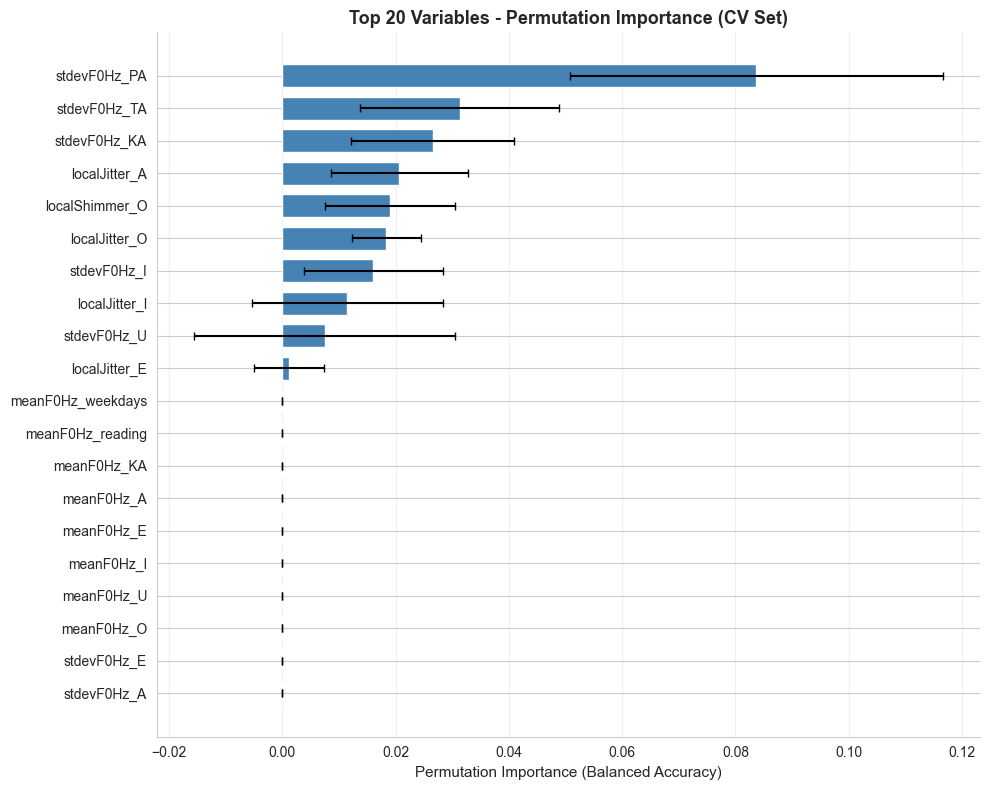


Resultados guardados en: C:\Users\Laura\OneDrive\TFG\results\02_rf_v1_0\permutation_importance.csv


In [60]:
print("\n" + "="*80)
print("CALCULANDO PERMUTATION IMPORTANCE (puede tardar 1-2 minutos)")
print("="*80)

# Calcular permutation importance en CV set
perm_importance = permutation_importance(
    best_model,
    X_cv_clean,
    y_cv_enc,
    n_repeats=10,
    random_state=SEED,
    scoring='balanced_accuracy',
    n_jobs=-1
)

# Obtener nombres de features después del preprocesamiento
try:
    selector = best_model.named_steps['feature_selection']
    preprocessor_step = best_model.named_steps['preprocessing']
    
    feature_names_after_preprocessing = preprocessor_step.get_feature_names_out()
    selected_mask = selector.get_support()
    selected_features = feature_names_after_preprocessing[selected_mask]
    
except:
    k_best = best_model.named_steps['feature_selection'].k
    selected_features = [f"feature_{i}" for i in range(k_best)]

# Crear DataFrame con importancias
perm_imp_df = pd.DataFrame({
    'Feature': X_cv_clean.columns,
    'Importance_mean': perm_importance.importances_mean,
    'Importance_std': perm_importance.importances_std
}).sort_values('Importance_mean', ascending=False)

print("\nPermutation importance calculada")
print(f"\nTop 15 variables más importantes (Permutation Importance):")
print(perm_imp_df.head(15).to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(20, len(perm_imp_df))
top_features = perm_imp_df.head(top_n)

ax.barh(
    range(top_n),
    top_features['Importance_mean'][::-1],
    xerr=top_features['Importance_std'][::-1],
    color='steelblue',
    edgecolor='white',
    height=0.7,
    capsize=3
)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['Feature'][::-1])
ax.set_xlabel('Permutation Importance (Balanced Accuracy)', fontsize=11)
ax.set_title(f'Top {top_n} Variables - Permutation Importance (CV Set)', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'permutation_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Guardar CSV
perm_imp_df.to_csv(RESULTS_PATH / 'permutation_importance.csv', index=False)
print(f"\nResultados guardados en: {RESULTS_PATH / 'permutation_importance.csv'}")

<div style="color:#6593BA;">
    <span style="font-size:17px; font-weight:bold;"> 20.2 MDI (Mean Decrease Impurity)</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El MDI coincide cualitativamente con la permutation importance en señalar las métricas de variabilidad de F0 como las más relevantes, con un ranking más distribuido entre las features seleccionadas (k=10). Las tres primeras son <b>stdevF0Hz_PA</b> (0.196), <b>stdevF0Hz_U</b> (0.153) y <b>stdevF0Hz_KA</b> (0.127), seguidas de <b>localJitter_I</b> (0.112), <b>stdevF0Hz_TA</b> (0.080) y <b>localShimmer_O</b> (0.075). Tanto MDI como permutation coinciden en colocar <code>stdevF0Hz_PA</code> como la feature más informativa por un margen amplio. La concentración de relevancia en tareas de diadococinesia (PA, KA, TA) y en vocales sostenidas (U, I) es coherente: estas pruebas exigen coordinación rápida y sostenida del aparato fonatorio, donde el déficit motor neuronal de la ELA se manifiesta de forma más pronunciada.
    </span>
</div>


Top 15 variables más importantes (MDI):
            Feature  Importance
  num__stdevF0Hz_PA    0.195993
   num__stdevF0Hz_U    0.152962
  num__stdevF0Hz_KA    0.126983
 num__localJitter_I    0.112487
  num__stdevF0Hz_TA    0.080457
num__localShimmer_O    0.075216
   num__stdevF0Hz_I    0.072007
 num__localJitter_O    0.062710
 num__localJitter_E    0.062462
 num__localJitter_A    0.058723


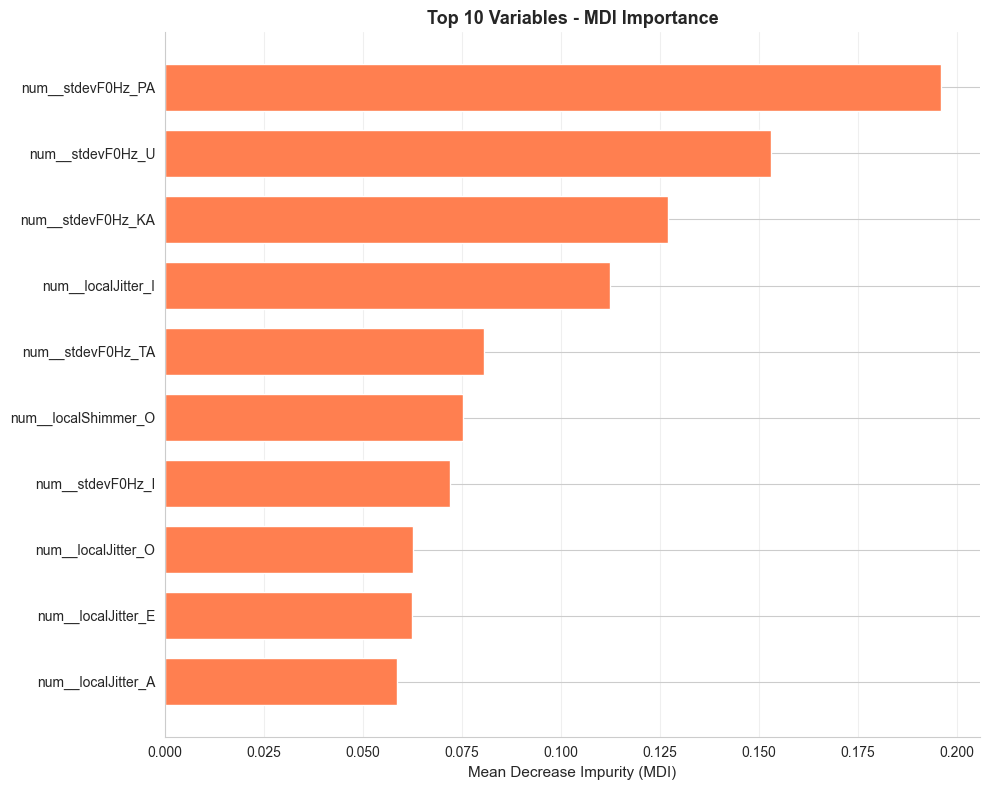


Resultados guardados en: C:\Users\Laura\OneDrive\TFG\results\02_rf_v1_0\mdi_importance.csv


In [61]:
# Extraer importancias MDI del Random Forest
rf_classifier = best_model.named_steps['classifier']
mdi_importances = rf_classifier.feature_importances_

# Crear DataFrame
mdi_imp_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': mdi_importances
}).sort_values('Importance', ascending=False)

print("\nTop 15 variables más importantes (MDI):")
print(mdi_imp_df.head(15).to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(20, len(mdi_imp_df))
top_features_mdi = mdi_imp_df.head(top_n)

ax.barh(
    range(top_n),
    top_features_mdi['Importance'][::-1],
    color='coral',
    edgecolor='white',
    height=0.7
)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features_mdi['Feature'][::-1])
ax.set_xlabel('Mean Decrease Impurity (MDI)', fontsize=11)
ax.set_title(f'Top {top_n} Variables - MDI Importance', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'mdi_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Guardar CSV
mdi_imp_df.to_csv(RESULTS_PATH / 'mdi_importance.csv', index=False)
print(f"\nResultados guardados en: {RESULTS_PATH / 'mdi_importance.csv'}")

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 21. Evaluación final en Test Set</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El <b>test set</b> representa la evaluación final y definitiva del modelo en datos completamente no vistos. Este conjunto no ha participado en ninguna decisión de modelado:
<ul>
<li>No se usó para optimizar hiperparámetros</li>
<li>No se usó para seleccionar features</li>
<li>No se usó para ajustar ningún parámetro del preprocesamiento</li>
<li>No se vio durante el nested cross-validation</li>
</ul>
<br>
Las métricas en test set proporcionan la estimación más representativa del rendimiento esperado en producción, al evaluar el modelo en condiciones idénticas a las que enfrentaría con pacientes nuevos.
<br><br>
<b>Punto importante de interpretación:</b> Si las métricas en test difieren significativamente de las observadas en nested CV, esto puede indicar overfitting residual o simplemente variabilidad natural debida al tamaño muestral pequeño. En datasets pequeños (n<200), es esperable cierta variabilidad entre particiones.
<br><br>
La evaluación definitiva sobre test debe interpretarse exclusivamente a partir de la ejecución actual del notebook, ya que las métricas previas quedaron afectadas tanto por el cambio de protocolo (<b>CV + Test</b>) como por la corrección del bug en el mapeo de etiquetas. El objetivo de esta celda es consolidar el hold-out final como única estimación independiente del rendimiento tras seleccionar hiperparámetros y entrenar el modelo con todo el conjunto CV.
    </span> 
</div>

In [62]:
# EVALUACIÓN FINAL EN TEST SET
y_test_pred  = best_model.predict(X_test_clean)
y_test_proba = best_model.predict_proba(X_test_clean)[:, ALS_LABEL]

test_acc            = accuracy_score(y_test_enc, y_test_pred)
test_bal_acc        = balanced_accuracy_score(y_test_enc, y_test_pred)
test_recall_als     = recall_score(y_test_enc,    y_test_pred, pos_label=ALS_LABEL, zero_division=0)
test_recall_hc      = recall_score(y_test_enc,    y_test_pred, pos_label=HC_LABEL,  zero_division=0)
test_precision_als  = precision_score(y_test_enc, y_test_pred, pos_label=ALS_LABEL, zero_division=0)
test_precision_hc   = precision_score(y_test_enc, y_test_pred, pos_label=HC_LABEL,  zero_division=0)
test_f1_als         = f1_score(y_test_enc,        y_test_pred, pos_label=ALS_LABEL, zero_division=0)
test_auc            = roc_auc_score(y_test_enc == ALS_LABEL, y_test_proba)

print("" + "="*80)
print("EVALUACIÓN FINAL EN TEST SET")
print("="*80)
print(f"Accuracy:             {test_acc:.4f}")
print(f"Balanced Accuracy:    {test_bal_acc:.4f}")
print(f"Recall  ALS:          {test_recall_als:.4f}")
print(f"Recall  HC:           {test_recall_hc:.4f}")
print(f"Precision ALS:        {test_precision_als:.4f}")
print(f"Precision HC:         {test_precision_hc:.4f}")
print(f"F1 ALS:               {test_f1_als:.4f}")
print(f"ROC-AUC (ALS vs HC):  {test_auc:.4f}")
print("Classification report:")
print(classification_report(y_test_enc, y_test_pred, target_names=le.classes_))

# Persistencia
test_predictions_df = pd.DataFrame({
    ID_COL:     df_test[ID_COL].values,
    "y_true":   y_test_enc,
    "y_pred":   y_test_pred,
    "prob_ALS": y_test_proba,
})
test_predictions_df.to_csv(RESULTS_PATH / "test_predictions.csv", index=False)
print(f"Test predictions: {RESULTS_PATH / 'test_predictions.csv'}")

test_metrics_dict = {
    "accuracy":          float(test_acc),
    "balanced_accuracy": float(test_bal_acc),
    "recall_als":        float(test_recall_als),
    "recall_hc":         float(test_recall_hc),
    "precision_als":     float(test_precision_als),
    "precision_hc":      float(test_precision_hc),
    "f1_als":            float(test_f1_als),
    "roc_auc":           float(test_auc),
}
save_metrics(
    test_metrics_dict,
    RESULTS_PATH / "test_metrics.json",
    model_name="rf_v1.0",
    phase="test",
    extra={"n_subjects_test": int(len(X_test_clean))},
)

# Log en MLflow como run nested del padre
with mlflow.start_run(run_id=PARENT_RUN_ID):
    with mlflow.start_run(run_name="test_eval", nested=True):
        for m, v in test_metrics_dict.items():
            mlflow.log_metric(f"test_{m}", v)
        mlflow.log_artifact(str(RESULTS_PATH / "test_predictions.csv"))
        mlflow.log_artifact(str(RESULTS_PATH / "test_metrics.json"))

EVALUACIÓN FINAL EN TEST SET
Accuracy:             0.6087
Balanced Accuracy:    0.5982
Recall  ALS:          0.6250
Recall  HC:           0.5714
Precision ALS:        0.7692
Precision HC:         0.4000
F1 ALS:               0.6897
ROC-AUC (ALS vs HC):  0.6071
Classification report:
              precision    recall  f1-score   support

         ALS       0.77      0.62      0.69        16
          HC       0.40      0.57      0.47         7

    accuracy                           0.61        23
   macro avg       0.58      0.60      0.58        23
weighted avg       0.66      0.61      0.62        23

Test predictions: C:\Users\Laura\OneDrive\TFG\results\02_rf_v1_0\test_predictions.csv
Guardado: C:\Users\Laura\OneDrive\TFG\results\02_rf_v1_0\test_metrics.json


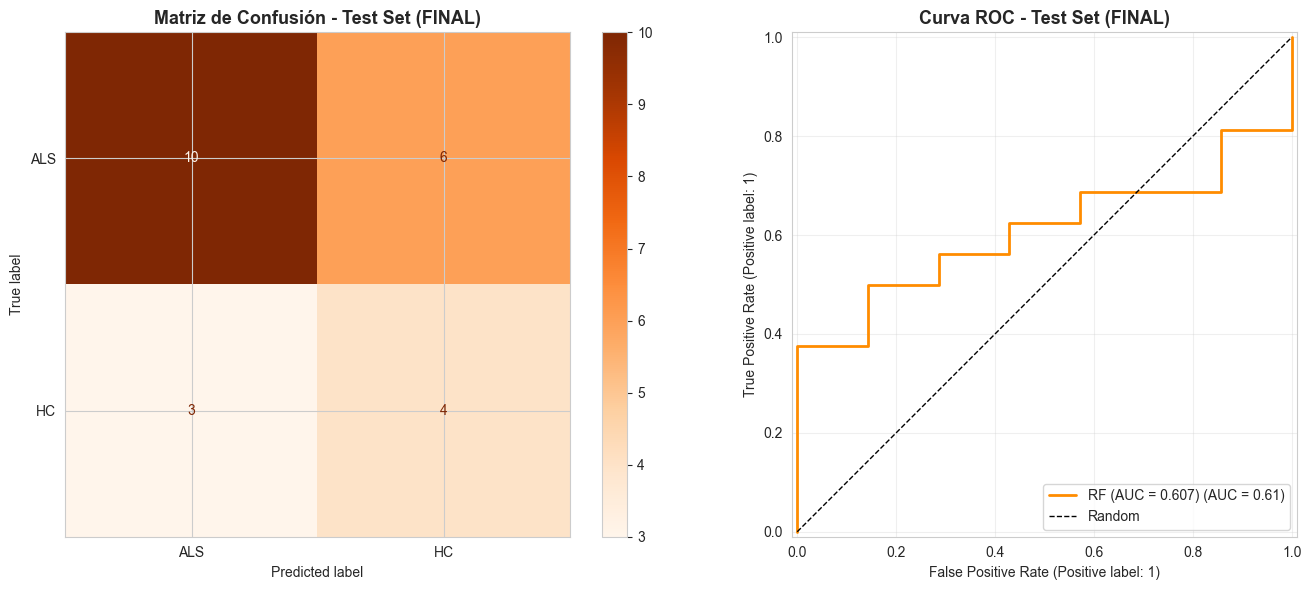


Visualizaciones guardadas en: C:\Users\Laura\OneDrive\TFG\results\02_rf_v1_0\test_set_evaluation.png


In [63]:
# Visualizaciones de test set
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Matriz de confusión
cm_test = confusion_matrix(y_test_enc, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=le.classes_)
disp.plot(cmap='Oranges', ax=axes[0], values_format='d')
axes[0].set_title('Matriz de Confusión - Test Set (FINAL)', fontsize=13, fontweight='bold')

# Curva ROC
RocCurveDisplay.from_predictions(
    y_test_enc == ALS_LABEL, y_test_proba,
    ax=axes[1],
    name=f'RF (AUC = {test_auc:.3f})',
    color='darkorange',
    lw=2
)
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[1].set_title('Curva ROC - Test Set (FINAL)', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_PATH / 'test_set_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualizaciones guardadas en:", RESULTS_PATH / 'test_set_evaluation.png')

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 22. Análisis FP/FN en Test</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El bloque siguiente construye el DataFrame completo de errores sobre test usando el mapeo verificado de etiquetas (<code>ALS_LABEL</code>, <code>HC_LABEL</code>). Tras la corrección del bug de <code>LabelEncoder</code>, las categorías quedan definidas de forma consistente: <b>FP</b> = sujeto HC clasificado como ALS, <b>FN</b> = sujeto ALS clasificado como HC. En la ejecución actual el modelo produce <b>3 falsos positivos</b> (3 de los 7 controles sanos del test mal clasificados como ALS) y <b>6 falsos negativos</b> (6 de los 16 pacientes ALS mal clasificados como HC). El sesgo es claramente hacia el lado de baja sensibilidad (recall ALS = 0.625 vs. recall HC = 0.571 sobre muestras pequeñas), patrón habitual en clasificadores con clase minoritaria HC y prior bayesiano dominado por ALS pese al <code>class_weight='balanced'</code>.
    </span>
</div>

In [64]:
# DataFrame con resultados del test
test_results = pd.DataFrame({
    "y_true": y_test_enc,
    "y_pred": y_test_pred,
    "prob_ALS": y_test_proba,
}, index=df_test.index)

# FP: predicho ALS pero es HC
fp_idx = test_results[(test_results["y_true"] == HC_LABEL)  & (test_results["y_pred"] == ALS_LABEL)].index
# FN: predicho HC pero es ALS
fn_idx = test_results[(test_results["y_true"] == ALS_LABEL) & (test_results["y_pred"] == HC_LABEL)].index

# Recuperar TODAS las columnas del subset de test
fp_df = df_test.loc[fp_idx].copy()
fn_df = df_test.loc[fn_idx].copy()

# Añadir información de predicción
fp_df["Predicted_Label"] = le.inverse_transform(test_results.loc[fp_idx, "y_pred"])
fp_df["True_Label"] = le.inverse_transform(test_results.loc[fp_idx, "y_true"])
fp_df["Prob_ALS"] = test_results.loc[fp_idx, "prob_ALS"]
fp_df["Error_Type"] = "False Positive"

fn_df["Predicted_Label"] = le.inverse_transform(test_results.loc[fn_idx, "y_pred"])
fn_df["True_Label"] = le.inverse_transform(test_results.loc[fn_idx, "y_true"])
fn_df["Prob_ALS"] = test_results.loc[fn_idx, "prob_ALS"]
fn_df["Error_Type"] = "False Negative"

# Combinar
errors_full_df = pd.concat([fp_df, fn_df])
display(errors_full_df)

print(f"\nFalse Positives: {len(fp_df)}")
print(f"False Negatives: {len(fn_df)}")

,ID,Age (years),Sex,Category,OnsetRegion,Therapy,GeneticTest,DiagnosticDelay,DiseaseDuration,FVC%,...,meanF0Hz_weekdays,stdevF0Hz_weekdays,HNR_weekdays,localJitter_weekdays,localShimmer_weekdays,Cantagallo_Questionnaire,Predicted_Label,True_Label,Prob_ALS,Error_Type
0,CT014,62,F,HC,-,-,-,-,-,-,...,184.407533,30.296640,13.525610,0.028864,0.123836,3,ALS,HC,0.588773,False Positive
3,CT053,68,M,HC,-,-,-,-,-,-,...,96.832042,9.479091,9.087288,0.029501,0.139250,18,ALS,HC,0.714996,False Positive
5,CT067,79,M,HC,-,-,-,-,-,-,...,121.501412,12.602775,9.752492,0.030024,0.153914,0,ALS,HC,0.512044,False Positive
8,PZ016,59,M,ALS,bulbar,NaN,negative,2,2,104,...,142.072754,10.340686,15.342980,0.016664,0.081551,31,HC,ALS,0.291246,False Negative
11,PZ058,49,M,ALS,spinal,Riluzole,negative,19,25,96,...,94.439141,11.578909,11.571253,0.026462,0.099976,99,HC,ALS,0.285729,False Negative
16,PZ094,51,M,ALS,spinal,Riluzole,negative,8,9,89,...,94.570705,17.114239,9.138906,0.036094,0.153001,8,HC,ALS,0.305009,False Negative
17,PZ098,64,M,ALS,spinal,NaN,negative,19,19,95,...,138.279664,15.413763,16.802718,0.020213,0.084023,18,HC,ALS,0.371352,False Negative
18,PZ099,57,M,ALS,spinal,NaN,negative,16,16,105,...,161.483256,29.919358,14.913770,0.027560,0.101287,43,HC,ALS,0.458558,False Negative
20,PZ105,65,M,ALS,bulbar,NaN,C9ORF72 expansion,2,2,110,...,105.172691,16.698328,12.797064,0.020859,0.095026,35,HC,ALS,0.394818,False Negative



False Positives: 3
False Negatives: 6


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 5. CALIBRACIÓN DE PROBABILIDADES</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
La calibración de probabilidades ajusta las probabilidades predichas por el modelo para que reflejen mejor las frecuencias observadas de cada clase. Un modelo bien calibrado predice probabilidades que coinciden con las tasas reales: si predice 70% de probabilidad para ALS en 100 casos, aproximadamente 70 de esos casos deberían ser realmente ALS.
<br><br>
Se implementan dos técnicas de calibración:
<br>
<ul>
<li><b>Platt Scaling (sigmoid):</b> Ajusta una regresión logística sobre las probabilidades crudas del Random Forest. Es paramétrico y funciona bien incluso con conjuntos de calibración pequeños.</li>
<li><b>Isotonic Regression:</b> Mapeo no paramétrico más flexible que Platt. Útil cuando las desviaciones de calibración no siguen una forma sigmoidal simple.</li>
</ul>
<br>
La evaluación se realiza mediante <b>Brier Score</b> (penaliza probabilidades mal calibradas, valores más bajos son mejores) y <b>curvas de calibración</b> que visualizan la correspondencia entre probabilidades predichas y frecuencias observadas.
    </span> 
</div>


<br>
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 23. Entrenamiento de modelos calibrados</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Se entrenan dos modelos calibrados sobre el conjunto CV (cv=5) y se evalúan sobre el test set. El modelo <b>original</b> obtiene ROC-AUC 0.607, balanced accuracy 0.598 y Brier score 0.232. El modelo <b>Platt (sigmoid)</b> obtiene ROC-AUC 0.545, balanced accuracy 0.438 y Brier score 0.214. El modelo <b>isotónico</b> obtiene ROC-AUC 0.545, balanced accuracy 0.375 y Brier score 0.210. Aunque la calibración mejora ligeramente el Brier score (−0.018 con Platt, −0.022 con isotónico), lo hace a costa de una caída sustancial en balanced accuracy (−0.160 con Platt, −0.223 con isotónico) y en ROC-AUC (−0.063 con ambos). Con sólo 23 sujetos en test y un calibrador entrenado sobre los ~130 del CV, los métodos de post-procesamiento introducen suficiente varianza como para perjudicar la capacidad discriminativa. Conclusión: el modelo original sin calibrar sigue siendo el más adecuado para las fases siguientes, pendiente de revisar si v2.0 (acústicas + demográficas) cambia el cuadro.
    </span>
</div>

In [65]:
print("\n" + "="*80)
print("CALIBRACIÓN DE PROBABILIDADES DEL MODELO - Resultados sobre conjunto de test")
print("="*80)

# 1. MODELO ORIGINAL
proba_orig = best_model.predict_proba(X_test_clean)[:, ALS_LABEL]
pred_orig = best_model.predict(X_test_clean)

auc_orig = roc_auc_score(y_test_enc == ALS_LABEL, proba_orig)
brier_orig = brier_score_loss(y_test_enc == ALS_LABEL, proba_orig)
bal_acc_orig = balanced_accuracy_score(y_test_enc, pred_orig)

print("\nModelo ORIGINAL")
print(f"ROC-AUC:           {auc_orig:.4f}")
print(f"Balanced Accuracy: {bal_acc_orig:.4f}")
print(f"Brier Score:       {brier_orig:.4f}")

# 2. CALIBRACIÓN PLATT (SIGMOID)
cal_sigmoid = CalibratedClassifierCV(
    estimator=best_model,
    method="sigmoid",
    cv=5
)

cal_sigmoid.fit(X_cv_clean, y_cv_enc)

proba_sig = cal_sigmoid.predict_proba(X_test_clean)[:, ALS_LABEL]
pred_sig = cal_sigmoid.predict(X_test_clean)

auc_sig = roc_auc_score(y_test_enc == ALS_LABEL, proba_sig)
brier_sig = brier_score_loss(y_test_enc == ALS_LABEL, proba_sig)
bal_acc_sig = balanced_accuracy_score(y_test_enc, pred_sig)

print("\nModelo CALIBRADO (Platt Scaling - Sigmoid)")
print(f"ROC-AUC:           {auc_sig:.4f}")
print(f"Balanced Accuracy: {bal_acc_sig:.4f}")
print(f"Brier Score:       {brier_sig:.4f}")

# 3. CALIBRACIÓN ISOTONIC
cal_iso = CalibratedClassifierCV(
    estimator=best_model,
    method="isotonic",
    cv=5
)

cal_iso.fit(X_cv_clean, y_cv_enc)

proba_iso = cal_iso.predict_proba(X_test_clean)[:, ALS_LABEL]
pred_iso = cal_iso.predict(X_test_clean)

auc_iso = roc_auc_score(y_test_enc == ALS_LABEL, proba_iso)
brier_iso = brier_score_loss(y_test_enc == ALS_LABEL, proba_iso)
bal_acc_iso = balanced_accuracy_score(y_test_enc, pred_iso)

print("\nModelo CALIBRADO (Isotonic Regression)")
print(f"ROC-AUC:           {auc_iso:.4f}")
print(f"Balanced Accuracy: {bal_acc_iso:.4f}")
print(f"Brier Score:       {brier_iso:.4f}")

# RESUMEN COMPARATIVO
print("\n" + "="*80)
print("COMPARACIÓN FINAL")
print("="*80)

print(f"{'Modelo':<25} {'ROC-AUC':<10} {'BalAcc':<10} {'Brier':<10}")
print("-"*60)

print(f"{'Original':<25} {auc_orig:<10.4f} {bal_acc_orig:<10.4f} {brier_orig:<10.4f}")
print(f"{'Platt (sigmoid)':<25} {auc_sig:<10.4f} {bal_acc_sig:<10.4f} {brier_sig:<10.4f}")
print(f"{'Isotonic':<25} {auc_iso:<10.4f} {bal_acc_iso:<10.4f} {brier_iso:<10.4f}")

print("="*80)

# SUMMARY 
print(" "*80)
if brier_orig <= min(brier_sig, brier_iso):
    print("La calibración no mejora la calidad probabilística del modelo.")
else:
    print("La calibración mejora ligeramente la calidad probabilística (Brier).")

if bal_acc_orig >= max(bal_acc_sig, bal_acc_iso):
    print("Sin embargo, el modelo original mantiene mejor rendimiento de clasificación.")
print(" "*80)


CALIBRACIÓN DE PROBABILIDADES DEL MODELO - Resultados sobre conjunto de test

Modelo ORIGINAL
ROC-AUC:           0.6071
Balanced Accuracy: 0.5982
Brier Score:       0.2315

Modelo CALIBRADO (Platt Scaling - Sigmoid)
ROC-AUC:           0.5446
Balanced Accuracy: 0.4375
Brier Score:       0.2135

Modelo CALIBRADO (Isotonic Regression)
ROC-AUC:           0.5446
Balanced Accuracy: 0.3750
Brier Score:       0.2100

COMPARACIÓN FINAL
Modelo                    ROC-AUC    BalAcc     Brier     
------------------------------------------------------------
Original                  0.6071     0.5982     0.2315    
Platt (sigmoid)           0.5446     0.4375     0.2135    
Isotonic                  0.5446     0.3750     0.2100    
                                                                                
La calibración mejora ligeramente la calidad probabilística (Brier).
Sin embargo, el modelo original mantiene mejor rendimiento de clasificación.
                                            

<br>
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 24. Curvas ROC - CV vs Test</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Las curvas ROC comparan el comportamiento del modelo sobre el conjunto de <b>CV</b> y el <b>test final</b>, siempre usando la probabilidad de ALS como score positivo. La comparación visual permite comprobar si el rendimiento observado durante el desarrollo (CV) se sostiene en el conjunto hold-out. Los modelos calibrados se muestran como referencia adicional para valorar si mejoran o degradan la separación entre clases.
    </span>
</div>

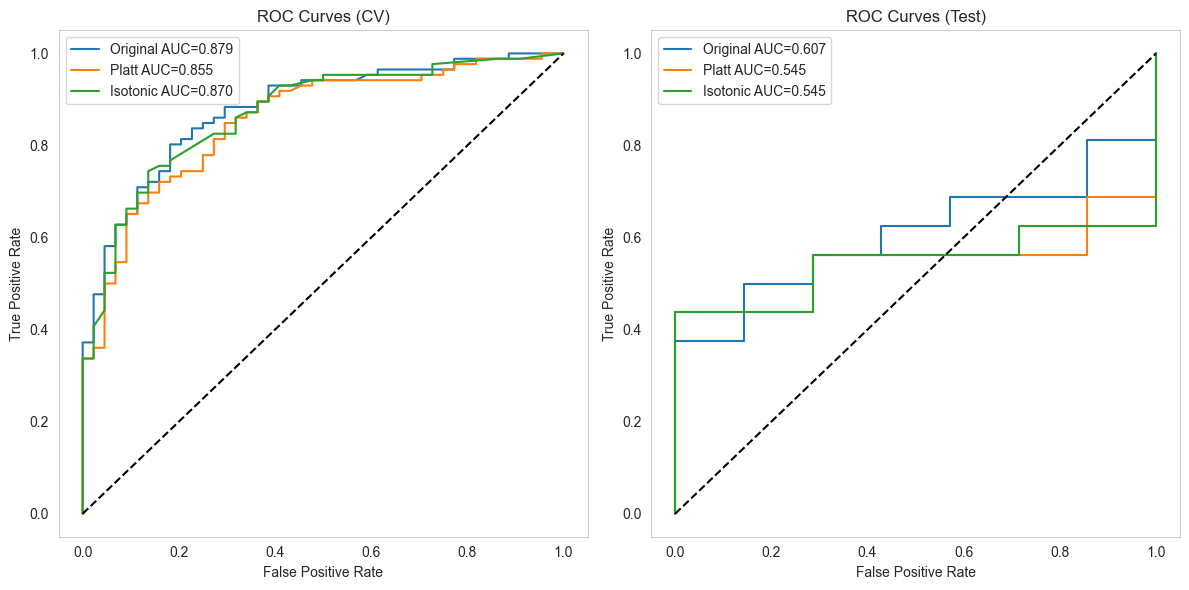

In [66]:
# CV PROBABILITIES
proba_cv_orig = best_model.predict_proba(X_cv_clean)[:, ALS_LABEL]
proba_cv_sig = cal_sigmoid.predict_proba(X_cv_clean)[:, ALS_LABEL]
proba_cv_iso = cal_iso.predict_proba(X_cv_clean)[:, ALS_LABEL]

# TEST PROBABILITIES
proba_test_orig = best_model.predict_proba(X_test_clean)[:, ALS_LABEL]
proba_test_sig = cal_sigmoid.predict_proba(X_test_clean)[:, ALS_LABEL]
proba_test_iso = cal_iso.predict_proba(X_test_clean)[:, ALS_LABEL]

# Crear figura con dos subplots
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# CV ROC
for probs, labels, name in [
    (proba_cv_orig, y_cv_enc, "Original"),
    (proba_cv_sig, y_cv_enc, "Platt"),
    (proba_cv_iso, y_cv_enc, "Isotonic")
]:
    
    fpr, tpr, _ = roc_curve(labels == ALS_LABEL, probs)
    roc_auc = auc(fpr, tpr)

    axes[0].plot(fpr, tpr, label=f"{name} AUC={roc_auc:.3f}")

axes[0].plot([0,1],[0,1],'k--')
axes[0].set_title("ROC Curves (CV)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid()

# TEST ROC
for probs, labels, name in [
    (proba_test_orig, y_test_enc, "Original"),
    (proba_test_sig, y_test_enc, "Platt"),
    (proba_test_iso, y_test_enc, "Isotonic")
]:
    
    fpr, tpr, _ = roc_curve(labels == ALS_LABEL, probs)
    roc_auc = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, label=f"{name} AUC={roc_auc:.3f}")

axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title("ROC Curves (Test)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

<br>
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 25. Curvas de calibración</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Las curvas de calibración comparan las probabilidades medias predichas en cada bin con las frecuencias reales observadas. Un modelo perfectamente calibrado seguiría la diagonal. En este caso, el número reducido de sujetos en el test set (23) limita la resolución de las curvas: con bins de 0.1, cada bin puede contener muy pocas o ninguna muestra, lo que hace que la curva sea poco interpretable en los extremos. Esta limitación es inherente al tamaño muestral y refuerza la conclusión de que la calibración no es viable con los datos disponibles.
    </span>
</div>

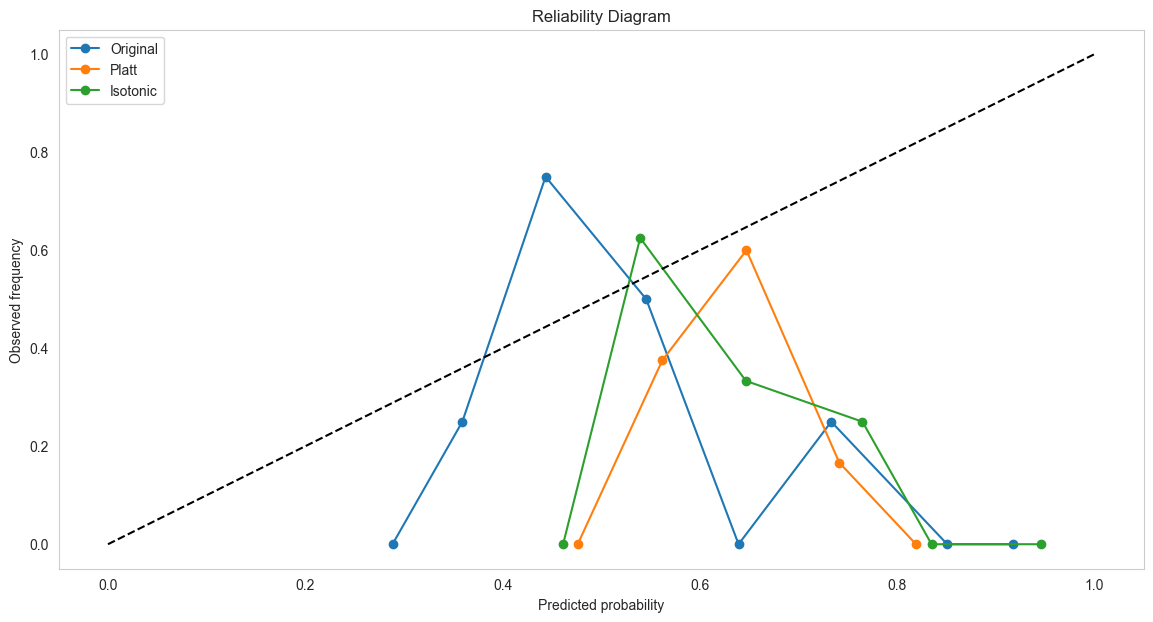

In [67]:
plt.figure(figsize=(14,7))

bins = np.linspace(0,1,11)

for probs, label in [
    (proba_orig,"Original"),
    (proba_sig,"Platt"),
    (proba_iso,"Isotonic")
]:

    binids = np.digitize(probs, bins) - 1
    bin_true = []
    bin_pred = []

    for i in range(len(bins)-1):

        mask = binids == i

        if np.sum(mask) > 0:

            bin_true.append(np.mean(y_test_enc[mask]))
            bin_pred.append(np.mean(probs[mask]))

    plt.plot(bin_pred, bin_true, marker="o", label=label)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Reliability Diagram")
plt.legend()
plt.grid()
plt.show()

<br>
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 26. Distribución de probabilidades</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El histograma de probabilidades predichas muestra cómo se distribuyen las salidas del modelo para los tres casos (original, Platt, isotónico). El modelo original tiende a concentrar las probabilidades en el rango medio (0.4–0.7), lo que es típico de los Random Forest que suelen comprimir las probabilidades hacia la media. Platt y la regresión isotónica redistribuyen esta concentración, pero en el caso del test set esto no mejora la separación entre clases.
    </span>
</div>

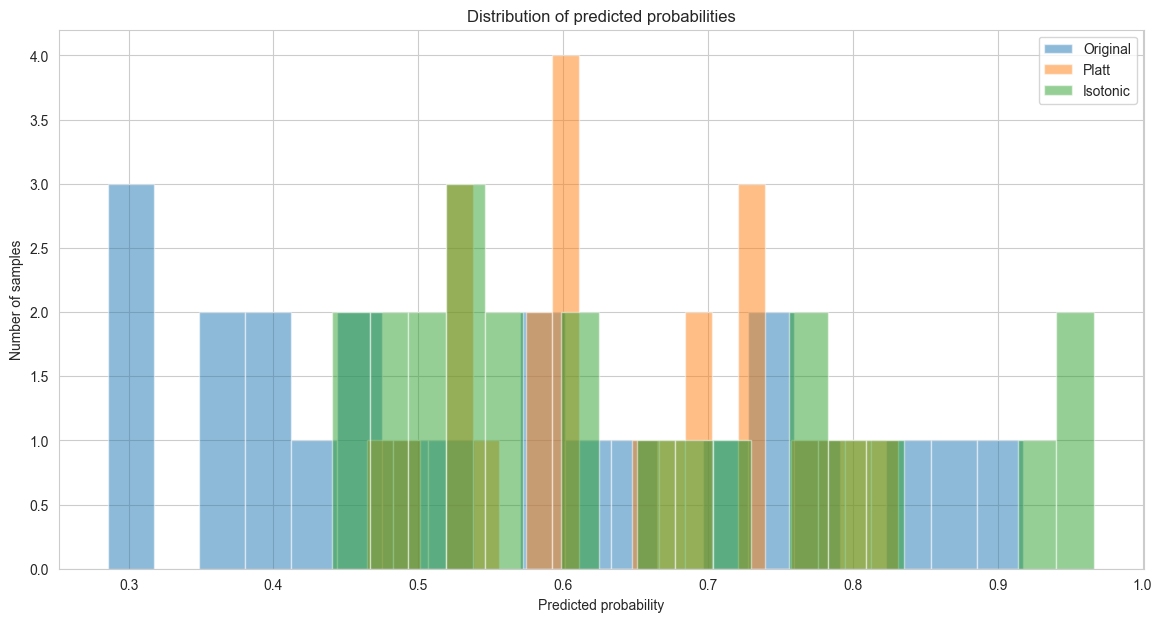

In [68]:
plt.figure(figsize=(14,7))

plt.hist(proba_orig, bins=20, alpha=0.5, label="Original")
plt.hist(proba_sig, bins=20, alpha=0.5, label="Platt")
plt.hist(proba_iso, bins=20, alpha=0.5, label="Isotonic")

plt.xlabel("Predicted probability")
plt.ylabel("Number of samples")
plt.title("Distribution of predicted probabilities")
plt.legend()

plt.show()

#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">CONCLUSIONES</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este notebook ha desarrollado un modelo Random Forest para clasificación binaria ALS vs. HC utilizando exclusivamente las <b>50 variables acústicas</b> del dataset VOC-ALS (5 prefijos × 10 tareas vocales). Las variables demográficas y clínicas se excluyen del espacio de features de forma explícita, dejando para v2.0 la comparación con un esquema que incorpore edad y sexo. A continuación se sintetizan los hallazgos principales:
<br>
<ul>
<li><b>Rendimiento del modelo:</b> El nested cross-validation (5×3 folds) sobre 130 sujetos del pool CV proporciona la estimación principal: balanced accuracy 0.582 ± 0.079, ROC-AUC 0.666 ± 0.062, recall ALS 0.639 ± 0.046, recall HC 0.525 ± 0.122. La evaluación final sobre los 23 sujetos de test produce balanced accuracy 0.598, ROC-AUC 0.607, recall ALS 0.625 y recall HC 0.571. La consistencia entre nested CV y test (gap < 0.06 en balanced accuracy y < 0.06 en AUC) indica que el modelo no sobre-ajusta, aunque la varianza inter-fold es notable y deja claras las limitaciones del tamaño muestral.</li><br>

<li><b>Hiperparámetros y selección de features:</b> El grid search (288 combinaciones × 3 inner folds × 5 outer folds = 4 320 ajustes en nested CV, más el refit final) selecciona <code>feature_selection__k=10</code>, <code>n_estimators=200</code>, <code>max_depth=5</code>, <code>min_samples_leaf=10</code>, <code>min_samples_split=10</code> y <code>class_weight='balanced'</code>, con un best inner CV score de 0.622 en balanced accuracy. La configuración es deliberadamente conservadora: árboles poco profundos con hojas grandes y sólo 10 features por modelo. La preferencia del grid por <i>k=10</i> (frente a 15 o 20) confirma que la información discriminativa se concentra en muy pocas features, en línea con lo que muestran los análisis de importancia.</li><br>

<li><b>Importancia de variables:</b> Permutation importance y MDI convergen en señalar las métricas de variabilidad de F0 como las más relevantes. <b>stdevF0Hz_PA</b> es la feature dominante en ambos rankings (Perm. 0.084, MDI 0.196), por encima de stdevF0Hz_TA, stdevF0Hz_KA y stdevF0Hz_U. Las métricas de jitter (localJitter_A, localJitter_O, localJitter_I) y shimmer (localShimmer_O) completan el top 10. La concentración de relevancia en tareas de diadococinesia (PA, TA, KA) y en vocales sostenidas es consistente con la fisiopatología de la disartria en ELA: el deterioro del control neuromuscular laríngeo se manifiesta especialmente en pruebas que exigen coordinación articulatoria rápida y sostenida del aparato fonatorio.</li><br>

<li><b>Análisis de errores:</b> El modelo produce 3 falsos positivos (3 de 7 HC mal clasificados como ALS) y 6 falsos negativos (6 de 16 ALS mal clasificados como HC). El sesgo es claramente hacia el lado de baja sensibilidad para ALS, pese al <code>class_weight='balanced'</code>. La revisión sujeto a sujeto sugiere que algunos FN son pacientes con valores de stdevF0Hz_PA en el rango de los HC (es decir, el biomarcador dominante no captura todos los fenotipos de ELA), lo que abre la cuestión de si añadir información demográfica mejora la cobertura — pregunta que v2.0 responderá.</li><br>

<li><b>Calibración de probabilidades:</b> Los modelos calibrados (Platt scaling e Isotonic regression) no mejoran la capacidad discriminativa del modelo original. Aunque el Brier score mejora ligeramente con Platt (0.214 vs. 0.232) e isotónico (0.210 vs. 0.232), esto se produce a costa de una caída sustancial en ROC-AUC (0.545 vs. 0.607) y balanced accuracy (0.438 con Platt, 0.375 con isotónico, vs. 0.598 original). Con sólo 23 sujetos en test, la calibración introduce más varianza de la que corrige. El modelo original sin calibrar es el más adecuado para las fases siguientes del proyecto.</li>
</ul>
<br>
En conjunto, los resultados apoyan que las <b>variables acústicas contienen información discriminativa relevante para la clasificación ALS vs. HC</b>, concentrada principalmente en métricas de variabilidad e inestabilidad vocal en tareas de diadococinesia. El nivel de rendimiento (balanced accuracy ≈ 0.58–0.60, ROC-AUC ≈ 0.61–0.67) es modesto pero coherente con la dificultad estructural del problema documentada en NB01 (clases parcialmente solapadas en PCA/t-SNE) y con el tamaño muestral disponible (n = 153). Este baseline queda preparado para comparaciones más fiables en v2.0 (acústicas + edad + sexo) y NB04 (BiLSTM sobre espectrogramas).
    </span>
</div>

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 27. Resumen de las conclusiones finales</span>
</div>

In [69]:
# TABLA RESUMEN FINAL
results_v1_summary = pd.DataFrame([
    {
        "Conjunto":     "CV (nested 5×3 SGKF)",
        "N":            len(X_cv_clean),
        "Accuracy":     cv_metrics_dict["accuracy"]["mean"],
        "Balanced Acc": cv_metrics_dict["balanced_accuracy"]["mean"],
        "Recall ALS":   cv_metrics_dict["recall_als"]["mean"],
        "Recall HC":    cv_metrics_dict["recall_hc"]["mean"],
        "ROC-AUC":      cv_metrics_dict["roc_auc"]["mean"],
        "Std (BalAcc)": cv_metrics_dict["balanced_accuracy"]["std"],
    },
    {
        "Conjunto":     "Test (final)",
        "N":            len(X_test_clean),
        "Accuracy":     test_metrics_dict["accuracy"],
        "Balanced Acc": test_metrics_dict["balanced_accuracy"],
        "Recall ALS":   test_metrics_dict["recall_als"],
        "Recall HC":    test_metrics_dict["recall_hc"],
        "ROC-AUC":      test_metrics_dict["roc_auc"],
        "Std (BalAcc)": np.nan,
    },
])

print("" + "="*90)
print("RESUMEN FINAL — RF v1.0")
print("="*90)
print(results_v1_summary.to_string(
    index=False,
    float_format=lambda x: f"{x:.4f}" if not pd.isna(x) else "N/A"
))
results_v1_summary.to_csv(RESULTS_PATH / "results_summary.csv", index=False)
print(f"Resumen guardado: {RESULTS_PATH / 'results_summary.csv'}")

# MLflow final: log de los tres archivos clave
with mlflow.start_run(run_id=PARENT_RUN_ID):
    mlflow.log_artifact(str(RESULTS_PATH / "cv_metrics.json"))
    mlflow.log_artifact(str(RESULTS_PATH / "test_metrics.json"))
    mlflow.log_artifact(str(RESULTS_PATH / "cv_oof_predictions.csv"))
    mlflow.log_artifact(str(RESULTS_PATH / "test_predictions.csv"))
    mlflow.log_artifact(str(RESULTS_PATH / "results_summary.csv"))

RESUMEN FINAL — RF v1.0
            Conjunto   N  Accuracy  Balanced Acc  Recall ALS  Recall HC  ROC-AUC  Std (BalAcc)
CV (nested 5×3 SGKF) 130    0.6000        0.5821      0.6392     0.5250   0.6658        0.0788
        Test (final)  23    0.6087        0.5982      0.6250     0.5714   0.6071           NaN
Resumen guardado: C:\Users\Laura\OneDrive\TFG\results\02_rf_v1_0\results_summary.csv


<div style='background-color:#D4EDDA; padding:20px; border-left:5px solid #011b07; margin-top:20px; color:black;'>
    <span style='font-size:16px; font-family:Calibri;'>
<b>NOTEBOOK COMPLETADO </b>
<br><br>
Todos los experimentos han sido registrados en <b>MLflow</b>.
<br><br>
Para visualizar los resultados de forma interactiva:
<br>
<code style='background-color:#F8F9FA; padding:5px; border:1px solid #DEE2E6; color:black;'>
mlflow ui --backend-store-uri ./mlruns
</code>
<br><br>
Luego accede a: <a href='http://localhost:5000' style="color:black;">http://localhost:5000</a>
<br><br>
<b>Archivos generados:</b>
<ul>
<li><b>results_summary.csv</b> - Tabla comparativa de métricas</li>
<li><b>permutation_importance.csv</b> - Importancia por permutación</li>
<li><b>mdi_importance.csv</b> - Importancia MDI</li>
<li><b>*.png</b> - Visualizaciones (matrices de confusión, ROC, importancias)</li>
</ul>
    </span>
</div>